# Entregável 1 — Relatório de Aquisição dos Biossinais

**Disciplina:** Aquisição e Processamento de Biossinais  
**Equipe:** José Ferreira Lessa & Matheus Rocha Gomes da Silva  
**Orientador:** Prof. Dr. Victor Hugo C. de Albuquerque  
**Dataset:** PTB-XL — A Large Publicly Available Electrocardiography Dataset (PhysioNet)  
**Referência:** Wagner et al. (2020). PTB-XL, a large publicly available electrocardiography dataset. *Scientific Data*, 7(1), 154.  
**Data:** Março e Abril de 2026

---


## Objetivo

Este notebook descreve a etapa de **Aquisição dos Biossinais**, responsável por documentar as condições originais de aquisição do dataset PTB-XL, caracterizar a base de dados de forma demográfica e clínica, e realizar inspeções visuais do sinal bruto de ECG. São abordados:

1. **Contextualização do Dataset:** Caracterização do biossinal, do protocolo de aquisição, justificativa da taxa de amostragem via Teorema de Nyquist e análise de alguns metadados.
2. **Panorama Estatístico do Dataset:** Distribuição Demográfica, de superclasses, labels, statements de forma/ritmo e registros por pacientes.
3. **Visualização dos sinais brutos de ECG (12 derivações):** carregamento, visualização e análise espectral visual do sinal bruto.
5. **Enriquecimento dos Metadados e Salvamento**
6. **Síntese e Conexão com Notebooks posteriores**

> **Nota metodológica:** O PTB-XL é um dataset público de referência internacional, com coleta realizada em ambiente hospitalar controlado, validado por especialistas cardiologistas. Os sinais brutos (.hea/.dat no formato WFDB) são carregados diretamente, sem nenhum pré-processamento, preservando as características originais de aquisição.

Aqui não fazemos nenhuma transformação nos sinais — a saída é um arquivo de metadados enriquecido (`ptbxl_metadata_enriched.csv`) que servirá de base para todos os notebooks subsequentes do pipeline.

In [ ]:
# Descomente as linhas abaixo para instalar as dependências, se necessário
#import sys
#print(sys.executable)
#!{sys.executable} -m pip install -r ../../../requirements.txt

c:\Users\User\anaconda3\envs\myenv\python.exe


## 1. Importações, Configurações e Dependências

Bibliotecas necessárias:

- `os` para manipulação de diretórios e caminhos de arquivos.
- `ast` para conversão segura de strings em estruturas Python (listas, dicionários, etc.).
- `numpy` para operações numéricas e manipulação de arrays.
- `pandas` para manipulação e análise de dados estruturados.
- `matplotlib.pyplot` e `seaborn` para visualizações gráficas.
- `wfdb` para leitura e processamento de sinais fisiológicos no formato PhysioNet.
- `scipy.signal` para análise e processamento de sinais (ex: filtros e espectro).
- `pathlib.Path` para manipulação de caminhos de arquivos de forma segura e multiplataforma.
- `IPython.display` para exibição formatada de saídas em notebooks (como Markdown).
- `collections.Counter`: contagem rápida de elementos em listas ou iteráveis.
- `warnings` para controle e supressão de avisos durante a execução.


In [2]:
import os
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import wfdb
import scipy.signal as signal
from pathlib import Path
from IPython.display import display, Markdown
from collections import Counter
import warnings

warnings.filterwarnings('ignore', category=UserWarning)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

np.random.seed(42)

---
## 2. Download e Verificação do Dataset PTB-XL

O dataset PTB-XL está disponível publicamente no PhysioNet:  
https://physionet.org/content/ptb-xl/1.0.3/

A célula abaixo verifica se o dataset já está presente localmente antes de tentar download.


In [3]:
DATA_DIR = Path('../../../data/ptb-xl/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3')
print(f'Dados em : {DATA_DIR.resolve()}')

if not DATA_DIR.exists():
    print('Dataset não encontrado. Iniciando download do PhysioNet (pode levar vários minutos).')
    wfdb.dl_database('ptb-xl/1.0.3', dl_dir=str(DATA_DIR))
    print('Download concluído!')
else:
    arquivos_hea = list(DATA_DIR.rglob('*.hea'))
    print(f'Dataset encontrado em: {DATA_DIR.resolve()}')
    print(f'Arquivos de cabeçalho (.hea) localizados: {len(arquivos_hea)}')


Dados em : C:\Users\User\Desktop\repo-lessa\data\ptb-xl\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3
Dataset encontrado em: C:\Users\User\Desktop\repo-lessa\data\ptb-xl\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3
Arquivos de cabeçalho (.hea) localizados: 43598


## 3. Configurações Globais
Definimos aqui as constantes do projeto. Optamos pela amostragem de **100 Hz** pois cobre a banda diagnóstica do ECG (0,05–40 Hz) com margem, respeitando ao critério de Nyquist (`fs ≥ 80 Hz`), e reduz o custo computacional em 5× comparado à de 500 Hz.

Posteriormente essa justificativa de amostragem e explicação do Critério de Nyquist serão mais aprofundadadas na seção 1.3.



In [ ]:
FS = 100
N_LEADS = 12
LEAD_NAMES = ['I', 'II', 'III', 'aVL', 'aVR', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
FOLDS_TREINO = [1, 2, 3, 4, 5, 6, 7, 8]
FOLD_VAL = 9
FOLD_TEST = 10

FIGS_DIR = Path('../figuras')
OUT_DIR  = Path('../outputs')
for d in [FIGS_DIR, OUT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print('Configuração concluída.')
print(f'Figuras em: {FIGS_DIR.resolve()}')
print(f'Outputs em: {OUT_DIR.resolve()}')


Configuração concluída.
Figuras em: C:\Users\User\Desktop\repo-lessa\entregaveis\entregavel-1\figuras
Outputs em: C:\Users\User\Desktop\repo-lessa\entregaveis\entregavel-1\outputs


## 3. Carregamento dos Metadados Base
O PTB-XL organiza seus metadados em dois arquivos CSV principais.
 - O `ptbxl_database.csv` contém informações de cada registro (idade, sexo, dispositivo de coleta, diagnósticos, validação por especialistas, etc)
 - O `scp_statements.csv` traz o dicionário de códigos diagnósticos SCP-ECG.

In [5]:
print("Carregando ptbxl_database.csv...")
df = pd.read_csv(DATA_DIR / 'ptbxl_database.csv', index_col='ecg_id')

# Convertendo a coluna scp_codes de string para dicionário Python
df['scp_codes'] = df['scp_codes'].apply(ast.literal_eval)

print("Carregando scp_statements.csv...")
scp_statements = pd.read_csv(DATA_DIR / 'scp_statements.csv', index_col=0)

print(f"Dataset carregado: {df.shape[0]} registros e {df.shape[1]} colunas originais.")

Carregando ptbxl_database.csv...
Carregando scp_statements.csv...
Dataset carregado: 21799 registros e 27 colunas originais.


---
## Seção 1 — Contextualização do Dataset

### 1.1 O Sinal de ECG e sua Relevância Clínica
O biossinal utilizado é o **Eletrocardiograma (ECG)** de **12 derivações** no padrão clínico internacional, composto por:

| Grupo | Derivações | Região monitorada |
|-------|-----------|-------------------|
| Membros (bipolares) | I, II, III | Plano frontal |
| Membros (unipolares aumentadas) | aVR, aVL, aVF | Plano frontal |
| Precordiais | V1, V2, V3, V4, V5, V6 | Plano horizontal |

[Animação em Inglês explicando o ECG de 12 Derivações](https://www.alilamedicalmedia.com/pt/-/galleries/images-videos-by-medical-specialties/cardiology-and-vascular-diseases/-/medias/4d57ce72-0d39-4525-b523-329941b9edcf-ecg-de-12-derivacoes-explicado-animacao-em-ingles)

O ECG registra a atividade elétrica do coração ao longo do tempo através de eletrodos posicionados na superfície corporal. O padrão clínico utiliza 12 derivações que oferecem perspectivas complementares do mesmo fenômeno elétrico. É o padrão-ouro para diagnóstico de arritmias, isquemia miocárdica, hipertrofia e diversas outras condições cardíacas.

Cada derivação mostra a mesma sequência — despolarização atrial (onda P), despolarização ventricular (complexo QRS) e repolarização ventricular (onda T) — sob ângulos diferentes. Essa redundância é necessária: certos diagnósticos só aparecem em derivações específicas. Por exemplo, infarto anterior se manifesta em V1–V4; infarto inferior aparece em II, III e aVF.

[O que é complexo QRS?](https://www.linkedin.com/posts/carolnascimentto777_o-que-%C3%A9-complexo-qrs-o-complexo-qrs-%C3%A9-activity-7126330076274507776-JUxx?utm_source=social_share_send&utm_medium=member_desktop_web&rcm=ACoAAFZ5CzwB0me7CLrCu9z1MQS_sdETD5DMHxU)

[Como Reconhecer o Infarto no ECG](https://artmed.com.br/artigos/como-reconhecer-o-infarto-no-ecg)

---



In [6]:
# Contagem de registros e pacientes
n_registros = len(df)
n_pacientes = df['patient_id'].nunique()

# Equipamentos
equipamento = "Dispositivos Schiller AG (fabricante suíço)"
equipamentos_unicos = df['device'].dropna().astype(str).unique()
n_devices = len(equipamentos_unicos)
equipamento_texto = f"{n_devices} modelo(s) diferente(s): {', '.join(equipamentos_unicos)}" if n_devices > 0 else "Não disponível"

# Sites
sites_unicos = df['site'].dropna().astype(str).unique()
n_sites = len(sites_unicos)
sites_texto = f"{n_sites} site(s): {', '.join(sites_unicos)}" if n_sites > 0 else "Não disponível"

# Período de coleta
df['recording_date'] = pd.to_datetime(df['recording_date'], errors='coerce')
periodo_inicio = df['recording_date'].min().strftime('%B de %Y')
periodo_fim = df['recording_date'].max().strftime('%B de %Y')
periodo_coleta = f"{periodo_inicio} a {periodo_fim}"

# Derivações
derivacoes_col = ['I','II','III','aVL','aVR','aVF','V1','V2','V3','V4','V5','V6']
derivacoes_texto = f"{len(derivacoes_col)} padrão ({', '.join(derivacoes_col)})"

# Frequência
freq_original = "400 Hz → reamostrado p/ 500 Hz"
freq_downsampled = "100 Hz (decimação do sinal de 500 Hz)"

# Precisão e formato padrão
precisao = "16 bits, resolução de 1 µV/LSB"
formato = "WFDB (PhysioNet), arquivos `.dat` + `.hea`"

# Markdown 
md_texto = (f"""\
### 1.2 Protocolo de Aquisição Original

| Parâmetro | Valor |
|---|---|
| **Equipamento** | {equipamento} |
| **Período de coleta** | {periodo_coleta} |
| **Instituição** | Physikalisch-Technische Bundesanstalt (PTB), Berlim, Alemanha |
| **Registros** | {n_registros} registros de 10 segundos |
| **Pacientes** | {n_pacientes} pacientes distintos |
| **Dispositivos** | {equipamento_texto} |
| **Sites** | {sites_texto} |
| **Derivações** | {derivacoes_texto} |
| **Freq. original** | {freq_original} |
| **Freq. downsampled** | {freq_downsampled} |
| **Precisão** | {precisao} |
| **Formato** | {formato} |

[PTB-XL, a large publicly available electrocardiography dataset](../../../docs/research/PTB-XL%2C%20a%20large%20publicly%20available%20electrocardiography%20dataset.pdf)

""")

display(Markdown(md_texto))

### 1.2 Protocolo de Aquisição Original

| Parâmetro | Valor |
|---|---|
| **Equipamento** | Dispositivos Schiller AG (fabricante suíço) |
| **Período de coleta** | November de 1984 a June de 2001 |
| **Instituição** | Physikalisch-Technische Bundesanstalt (PTB), Berlim, Alemanha |
| **Registros** | 21799 registros de 10 segundos |
| **Pacientes** | 18869 pacientes distintos |
| **Dispositivos** | 11 modelo(s) diferente(s): CS-12   E, AT-6 C 5.0, AT-6 C, CS-12, AT-6 C 5.5, AT-6 C 5.8, AT-6 C 5.6, AT-6     6, AT-6 C 5.3, AT-60    3, CS100    3 |
| **Sites** | 51 site(s): 0.0, 3.0, 2.0, 1.0, 35.0, 16.0, 4.0, 39.0, 32.0, 17.0, 9.0, 10.0, 34.0, 44.0, 11.0, 30.0, 36.0, 13.0, 5.0, 12.0, 38.0, 15.0, 25.0, 8.0, 14.0, 20.0, 29.0, 24.0, 21.0, 26.0, 6.0, 22.0, 18.0, 28.0, 45.0, 41.0, 49.0, 40.0, 37.0, 27.0, 43.0, 7.0, 19.0, 48.0, 42.0, 33.0, 23.0, 46.0, 50.0, 47.0, 31.0 |
| **Derivações** | 12 padrão (I, II, III, aVL, aVR, aVF, V1, V2, V3, V4, V5, V6) |
| **Freq. original** | 400 Hz → reamostrado p/ 500 Hz |
| **Freq. downsampled** | 100 Hz (decimação do sinal de 500 Hz) |
| **Precisão** | 16 bits, resolução de 1 µV/LSB |
| **Formato** | WFDB (PhysioNet), arquivos `.dat` + `.hea` |

[PTB-XL, a large publicly available electrocardiography dataset](../../../docs/research/PTB-XL%2C%20a%20large%20publicly%20available%20electrocardiography%20dataset.pdf)



### 1.3 Justificativa do Critério de Nyquist
O dataset disponibiliza dois formatos de resolução temporal:

| Formato | Taxa de Amostragem | Amostras por registro (10s) | Uso recomendado |
|---------|-------------------|-----------------------------|-----------------|
| Alta resolução (HR) | **500 Hz** | 5.000 por derivação | Análise diagnóstica completa |
| Baixa resolução (LR) | **100 Hz** | 1.000 por derivação | Prototipagem / redução computacional |

**Fundamentação teórica — Teorema de Nyquist-Shannon:**

O teorema de Nyquist-Shannon estabelece que para reconstruir fielmente um sinal de banda limitada $f_{max}$, a taxa de amostragem $f_s$ deve satisfazer:

$$f_s \geq 2 \cdot f_{max}$$

Para o ECG clínico de 12 derivações, a *American Heart Association* (AHA) e o *American College of Cardiology* (ACC) recomendam preservar a faixa de **0,05 Hz a 150 Hz para diagnóstico completo**; contudo, eles também classificam o intervalo de **0,05 Hz a 40 Hz** como subótimo ( pois apenas exclui alta frequência do QRS, mas preserva a maior parte do sinal original ).

[kligfield-et-al-2007-recommendations-for-the-standardization-and-interpretation-of-the-electrocardiogram](../../../docs/research/kligfield-et-al-2007-recommendations-for-the-standardization-and-interpretation-of-the-electrocardiogram.pdf)

Portanto:

$$f_s^{\min} = 2 \times 40 = 80 \text{ Hz}$$



A taxa de **100 Hz** supera o critério de Nyquist com **margem de segurança de 25%** ($100/80 = 1{,}25\times$), garantindo:
- Reconstrução fidedigna com baixo *aliasing*
- Visualização das morfologias principais (P, QRS, T)
- Redução do custo computacional em 5x comparado à de 500 Hz

A versão de 500 Hz preserva detalhes de alta frequência do QRS e permite melhor análise espectral, mas multiplica o custo computacional deste trabalho em 5x, o que acaba não sendo vantajoso tendo em vista o caráter didático deste trabalho -- portanto, **utilizaremos 100 Hz como taxa principal** neste pipeline.

Contudo, idealmente, este pipeline pode ser plenamente reproduzido para os dados de amostragem de 500 Hz, o que seria necessário para análise de micro-potenciais tardios ou deep learning com resolução temporal fina.

---



In [7]:
# 1.4 Processo de Anotação dos Labels
pct_human = df['validated_by_human'].value_counts(normalize=True).get(True, 0) * 100
pct_auto = df['initial_autogenerated_report'].value_counts(normalize=True).get(True, 0) * 100

display(Markdown(f"""
### 1.4 Processo de Anotação dos Labels
O processo de rotulagem do PTB-XL seguiu múltiplas etapas: laudo inicial (por cardiologista ou gerado automaticamente), conversão para códigos SCP-ECG, revisão por segundo cardiologista, e anotação de qualidade do sinal.

- **{pct_human:.1f}%** dos registros possuem validação humana confirmada (`validated_by_human = True`).
- **{pct_auto:.1f}%** tiveram o laudo inicial gerado automaticamente pelo dispositivo ECG.
"""))

display(df['validated_by_human'].value_counts())
display(df['initial_autogenerated_report'].value_counts())


### 1.4 Processo de Anotação dos Labels
O processo de rotulagem do PTB-XL seguiu múltiplas etapas: laudo inicial (por cardiologista ou gerado automaticamente), conversão para códigos SCP-ECG, revisão por segundo cardiologista, e anotação de qualidade do sinal.

- **73.7%** dos registros possuem validação humana confirmada (`validated_by_human = True`).
- **31.3%** tiveram o laudo inicial gerado automaticamente pelo dispositivo ECG.


validated_by_human
True     16056
False     5743
Name: count, dtype: int64

initial_autogenerated_report
False    14986
True      6813
Name: count, dtype: int64

### 1.5 Verossimilhança dos Diagnósticos (Likelihood)
A coluna `scp_codes` armazena um dicionário onde cada chave é um código SCP e o valor é a verossimilhança (0–100%), que reflete o grau de certeza do cardiologista:

[O que é SCP-ECG?](https://en-wikipedia-org.translate.goog/wiki/SCP-ECG?_x_tr_sl=en&_x_tr_tl=pt&_x_tr_hl=pt&_x_tr_pto=tc)

| Likelihood | Significado |
|---|---|
| 0% | Statement de forma/ritmo (binário) ou certeza mínima |
| 15% | "Não se pode excluir" |
| 50% | "Possivelmente", "talvez" |
| 80% | "Compatível com" |
| 100% | Diagnóstico confirmado |

Para classificação, adotaremos o limiar de **likelihood ≥ 50** para considerar um diagnóstico como positivo.

In [8]:
# 1.6 Estrutura do Arquivo de Metadados — visão geral das colunas
display(Markdown("### 1.6 Estrutura do Arquivo de Metadados"))
display(Markdown("**Amostra dos dados brutos:**"))
display(df[['patient_id', 'age', 'sex', 'height', 'weight', 'report', 'scp_codes', 'validated_by_human', 'strat_fold']].head(5))

# Completude dos campos
pct_h = df['height'].notna().mean() * 100
pct_w = df['weight'].notna().mean() * 100
pct_ax = df['heart_axis'].notna().mean() * 100

display(Markdown(f"""
**Completude dos campos opcionais:**
- Altura: {pct_h:.1f}% preenchidos
- Peso: {pct_w:.1f}% preenchidos
- Eixo cardíaco: {pct_ax:.1f}% preenchidos
"""))

### 1.6 Estrutura do Arquivo de Metadados

**Amostra dos dados brutos:**

,patient_id,age,sex,height,weight,report,scp_codes,validated_by_human,strat_fold
ecg_id,,,,,,,,,
1,15709.0,56.0,1,NaN,63.0,sinusrhythmus periphere niederspannung,"{'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}",True,3
2,13243.0,19.0,0,NaN,70.0,sinusbradykardie sonst normales ekg,"{'NORM': 80.0, 'SBRAD': 0.0}",True,2
3,20372.0,37.0,1,NaN,69.0,sinusrhythmus normales ekg,"{'NORM': 100.0, 'SR': 0.0}",True,5
4,17014.0,24.0,0,NaN,82.0,sinusrhythmus normales ekg,"{'NORM': 100.0, 'SR': 0.0}",True,3
5,17448.0,19.0,1,NaN,70.0,sinusrhythmus normales ekg,"{'NORM': 100.0, 'SR': 0.0}",True,4



**Completude dos campos opcionais:**
- Altura: 32.0% preenchidos
- Peso: 43.2% preenchidos
- Eixo cardíaco: 61.2% preenchidos


---
## Seção 2 — Panorama Estatístico do Dataset

### 2.1 Distribuição Demográfica


--- QUALIDADE DOS DADOS (IDADE) ---
Pacientes com idade = 300 (>= 90 anos): 293 (1.34% do total)
Pacientes sem idade declarada: 0 (0.00% do total)
Foi optado por deletar estes valores da análise estatística, uma vez que não são precisos.

--- ESTATÍSTICAS DE IDADE (LIMPA) ---
Mín: 2.0 | Q1: 50.0 | Mediana: 61.0 | Média: 59.5 | Q3: 72.0 | Máx: 89.0


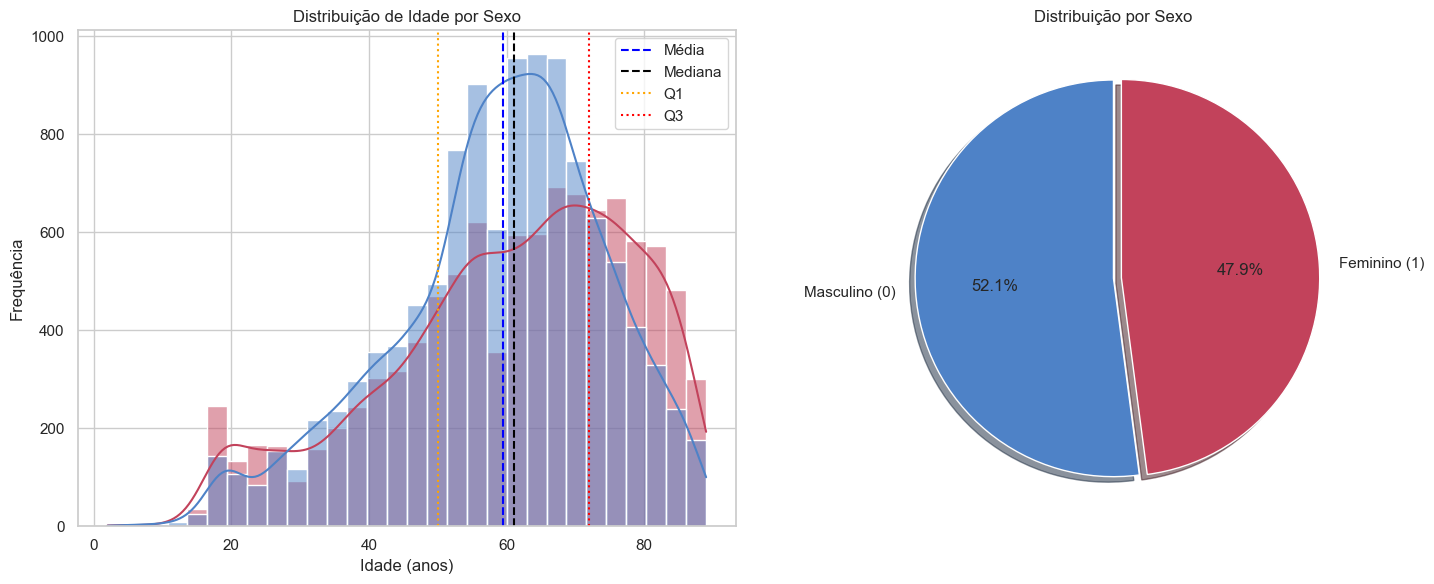

In [9]:
# =========================
# CONTAGEM INICIAL
# =========================
qtd_300 = (df['age'] == 300).sum()
qtd_nan_original = df['age'].isna().sum()

total = len(df)
pct_300 = qtd_300 / total * 100
pct_nan = qtd_nan_original / total * 100

print("\n--- QUALIDADE DOS DADOS (IDADE) ---")
print(f"Pacientes com idade = 300 (>= 90 anos): {qtd_300} ({pct_300:.2f}% do total)")
print(f"Pacientes sem idade declarada: {qtd_nan_original} ({pct_nan:.2f}% do total)")
print(f"Foi optado por deletar estes valores da análise estatística, uma vez que não são precisos.")

# =========================
# LIMPEZA
# =========================
df['age_clean'] = df['age'].replace(300, np.nan)

idade = df['age_clean'].dropna()

# =========================
# ESTATÍSTICAS
# =========================
min_id = idade.min()
max_id = idade.max()
mean_id = idade.mean()
median_id = idade.median()
q1_id = idade.quantile(0.25)
q3_id = idade.quantile(0.75)

print("\n--- ESTATÍSTICAS DE IDADE (LIMPA) ---")
print(f"Mín: {min_id:.1f} | Q1: {q1_id:.1f} | Mediana: {median_id:.1f} | Média: {mean_id:.1f} | Q3: {q3_id:.1f} | Máx: {max_id:.1f}")

# =========================
# PLOT
# =========================
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Histograma
sns.histplot(data=df, x='age_clean', hue='sex', bins=30,
             kde=True, ax=axes[0], alpha=0.5,
             palette=['#4e82c7', '#c2425b'])

# Linhas estatísticas
axes[0].axvline(mean_id, color='blue', linestyle='--', label='Média')
axes[0].axvline(median_id, color='black', linestyle='--', label='Mediana')
axes[0].axvline(q1_id, color='orange', linestyle=':', label='Q1')
axes[0].axvline(q3_id, color='red', linestyle=':', label='Q3')

axes[0].set_title('Distribuição de Idade por Sexo')
axes[0].set_xlabel('Idade (anos)')
axes[0].set_ylabel('Frequência')
axes[0].legend()

# Pizza (corrigindo ordenação)
sex_pct = df['sex'].value_counts(normalize=True).sort_index()

axes[1].pie(sex_pct,
            labels=['Masculino (0)', 'Feminino (1)'],
            autopct='%1.1f%%',
            colors=['#4e82c7', '#c2425b'],
            explode=(0, 0.04),
            shadow=True,
            startangle=90)

axes[1].set_title('Distribuição por Sexo')

plt.tight_layout()
fig.savefig(os.path.join(FIGS_DIR, 'distribuicao_demografica.png'),
            dpi=150, bbox_inches='tight')
plt.show()


--- PESO ---
Mín: 5.0 | Q1: 60.0 | Mediana: 70.0 | Média: 71.0 | Q3: 80.0 | Máx: 250.0

--- ALTURA ---
Mín: 6.0 | Q1: 160.0 | Mediana: 166.0 | Média: 166.7 | Q3: 174.0 | Máx: 209.0


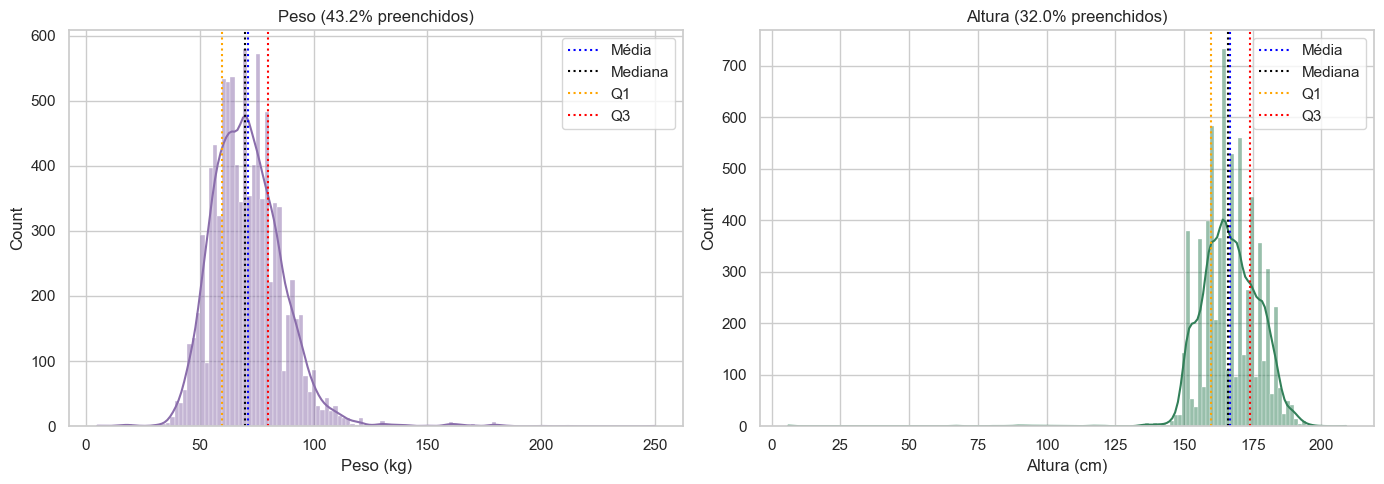

In [10]:
# --- Plot 2: Peso e Altura ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Percentual preenchido
pct_w = df['weight'].notna().mean() * 100
pct_h = df['height'].notna().mean() * 100

# =========================
# PESO
# =========================
peso = df['weight'].dropna()

min_w = peso.min()
max_w = peso.max()
mean_w = peso.mean()
median_w = peso.median()
q1_w = peso.quantile(0.25)
q3_w = peso.quantile(0.75)

# =========================
# ALTURA
# =========================
altura = df['height'].dropna()

min_h = altura.min()
max_h = altura.max()
mean_h = altura.mean()
median_h = altura.median()
q1_h = altura.quantile(0.25)
q3_h = altura.quantile(0.75)

# =========================
# PRINTS
# =========================
print("\n--- PESO ---")
print(f"Mín: {min_w:.1f} | Q1: {q1_w:.1f} | Mediana: {median_w:.1f} | Média: {mean_w:.1f} | Q3: {q3_w:.1f} | Máx: {max_w:.1f}")

print("\n--- ALTURA ---")
print(f"Mín: {min_h:.1f} | Q1: {q1_h:.1f} | Mediana: {median_h:.1f} | Média: {mean_h:.1f} | Q3: {q3_h:.1f} | Máx: {max_h:.1f}")

# =========================
# HISTOGRAMA - PESO
# =========================
sns.histplot(data=df, x='weight', kde=True, ax=axes[0], color='#8a6dab')

axes[0].axvline(mean_w, color='blue', linestyle=':', label='Média')
axes[0].axvline(median_w, color='black', linestyle=':', label='Mediana')
axes[0].axvline(q1_w, color='orange', linestyle=':', label='Q1')
axes[0].axvline(q3_w, color='red', linestyle=':', label='Q3')

axes[0].set_title(f'Peso ({pct_w:.1f}% preenchidos)')
axes[0].set_xlabel('Peso (kg)')
axes[0].legend()

# =========================
# HISTOGRAMA - ALTURA
# =========================
sns.histplot(data=df, x='height', kde=True, ax=axes[1], color='#328059')

axes[1].axvline(mean_h, color='blue', linestyle=':', label='Média')
axes[1].axvline(median_h, color='black', linestyle=':', label='Mediana')
axes[1].axvline(q1_h, color='orange', linestyle=':', label='Q1')
axes[1].axvline(q3_h, color='red', linestyle=':', label='Q3')

axes[1].set_title(f'Altura ({pct_h:.1f}% preenchidos)')
axes[1].set_xlabel('Altura (cm)')
axes[1].legend()

# Layout e salvamento
plt.tight_layout()
fig.savefig(os.path.join(FIGS_DIR, 'peso_altura.png'), dpi=150, bbox_inches='tight')
plt.show()

Total de registros: 21799


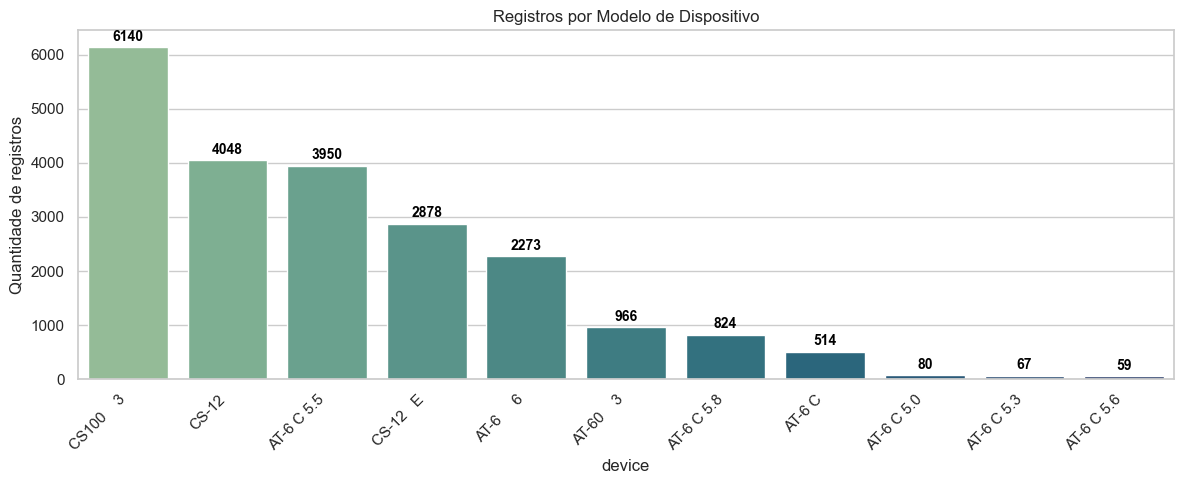

In [11]:
# --- Plot 3: Dispositivos ---
fig = plt.figure(figsize=(12, 5))

df_devices = df['device'].value_counts()
print(f"Total de registros: {df_devices.sum()}")

ax = sns.barplot(x=df_devices.index, y=df_devices.values, hue=df_devices.index, palette='crest')

# Adicionando os valores nas barras
for i, v in enumerate(df_devices.values):
    ax.text(i, v + max(df_devices.values)*0.01,  # leve offset acima da barra
            f'{v}',
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight='bold',
            color='black')

plt.title('Registros por Modelo de Dispositivo')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Quantidade de registros')

plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, 'dispositivos.png'), dpi=150, bbox_inches='tight')
plt.show()

**Comentários sobre a subseção 2.1:**

O dataset apresenta um bom nível de qualidade e balanceamento demográfico geral. Em relação à variável idade, observa-se que apenas 1,34% dos registros utilizam o valor 300 como forma de anonimização para pacientes com idade igual ou superior a 90 anos, e não há valores ausentes originalmente. Após a limpeza, a distribuição etária mostra uma mediana de 61 anos e média de 59,5 anos, com intervalo interquartil entre 50 e 72 anos. Essa concentração em faixas etárias mais elevadas é consistente com o contexto clínico de doenças cardíacas, que tendem a ser mais prevalentes em populações mais idosas. No entanto, a presença de valores mínimos muito baixos (por exemplo, 2 anos) sugere a inclusão de alguns casos pediátricos, que podem não ser o foco principal do dataset e merecem avaliação adicional.

Quanto ao sexo, a distribuição é bastante equilibrada (52,1% masculino e 47,9% feminino), o que é positivo para evitar vieses em análises e modelos preditivos. Esse balanceamento contribui para maior generalização dos resultados entre os dois grupos.

Em relação às variáveis antropométricas, os valores centrais de peso (mediana de 70 kg) e altura (mediana de 166 cm) são coerentes com uma população adulta. Entretanto, a presença de valores extremos, como peso mínimo de 5 kg e altura mínima de 6 cm, indica possíveis inconsistências ou registros atípicos, possivelmente relacionados a erros de coleta, unidades incorretas ou casos muito específicos. Esses outliers devem ser tratados com cautela, pois podem impactar análises estatísticas e modelos.

De forma geral, o dataset é coerente com um cenário clínico cardíaco, especialmente pela distribuição etária mais envelhecida e pelo bom balanceamento entre sexos. Ainda assim, recomenda-se uma etapa adicional de tratamento de outliers nas variáveis físicas para garantir maior robustez nas análises subsequentes.

****

### 2.2 Criação das Colunas de Distribuição de Superclasses Diagnósticas e Multi-label
O PTB-XL utiliza códigos SCP-ECG detalhados, mas para o nosso pipeline de classificação é mais prático agrupá-los em 5 superclasses diagnósticas: 
- **NORM** (normal), 
- **MI** (infarto do miocárdio), 
- **CD** (distúrbio de condução), 
- **STTC** (alterações ST/T) e 
- **HYP** (hipertrofia).

 A informação de mapeamento vem do próprio `scp_statements.csv`,
 
 Significados das siglas tirados de: [PTB-XL, a large publicly available electrocardiography dataset](../../../docs/research/PTB-XL%2C%20a%20large%20publicly%20available%20electrocardiography%20dataset.pdf)

In [12]:
# ==============================
# Superclasses (com threshold ≥ 0.5)
# ==============================

# Mapping (somente diagnósticos)
scp_diag = scp_statements[scp_statements['diagnostic'] == 1]
scp_to_superclass = scp_diag['diagnostic_class'].to_dict()

# Total de registros
total_registros = len(df)

# NOVA COLUNA
df['superclasses_clean'] = df['scp_codes'].apply(
    lambda x: list({
        scp_to_superclass[k]
        for k, v in x.items()
        if k in scp_to_superclass and v >= 0.5
    })
)

# Contagem por registro (nova coluna também)
df['n_superclasses'] = df['superclasses_clean'].apply(len)

# Explode usando a versão CLEAN
df_exploded = df.explode('superclasses_clean')

# Resumo
df_superclass_summary = (
    df_exploded['superclasses_clean']
    .value_counts()
    .rename_axis('Superclasse')
    .reset_index(name='Registros')
)

# Percentual
df_superclass_summary['Percentual (%)'] = (
    df_superclass_summary['Registros'] / total_registros * 100
).round(1)

# Multi-label
multi_label_counts = df['n_superclasses'].value_counts().sort_index()
multi_label_percent = (multi_label_counts / total_registros * 100).round(1)

=== Resumo de Superclasses Diagnósticas ===
Total de registros: 21799

NORM: 9514 registros (43.6% do total)
MI: 5469 registros (25.1% do total)
STTC: 5108 registros (23.4% do total)
CD: 4898 registros (22.5% do total)
HYP: 2649 registros (12.2% do total)

=== Distribuição Multi-label por Registro ===
0 superclasse(s) por registro: 424 registros (1.9%)
1 superclasse(s) por registro: 16307 registros (74.8%)
2 superclasse(s) por registro: 4024 registros (18.5%)
3 superclasse(s) por registro: 893 registros (4.1%)
4 superclasse(s) por registro: 151 registros (0.7%)


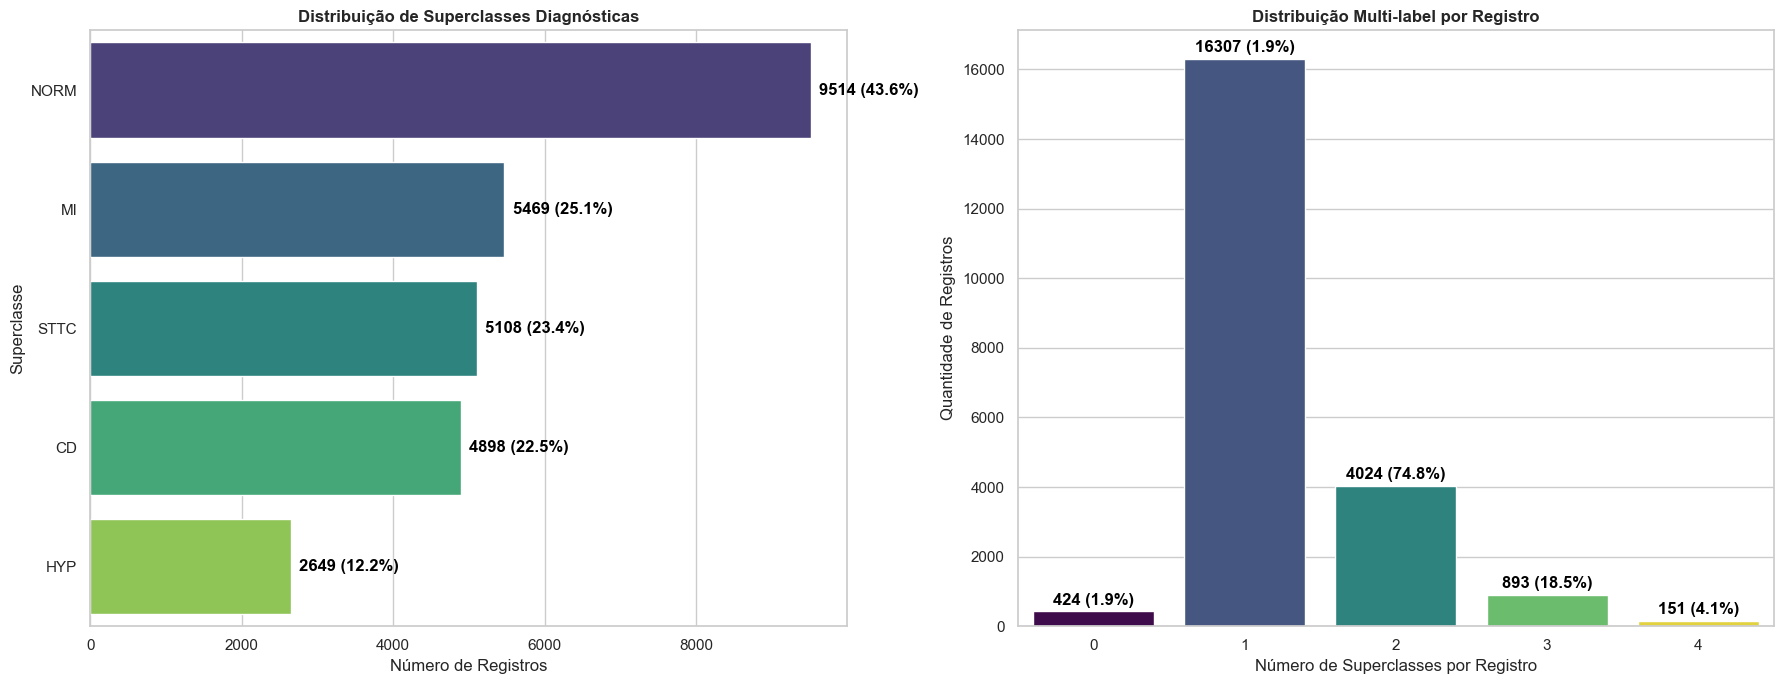

In [13]:
# ------------------------------
# Figura lado a lado: Superclasses e Multi-label (com contagem + percentual)
# ------------------------------
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Gráfico 1: Superclasses (horizontal) ---
sns.barplot(
    x='Registros',
    y='Superclasse',
    data=df_superclass_summary,
    hue='Superclasse',   # para evitar warning
    palette='viridis',
    dodge=False,
    ax=axes[0],
    legend=False
)

# Adiciona quantidade e percentual ao lado da barra
for index, row in df_superclass_summary.iterrows():
    axes[0].text(
        row['Registros'] + total_registros*0.005,
        index,
        f"{row['Registros']} ({row['Percentual (%)']}%)",
        va='center',
        fontweight='bold',
        color='black'
    )

axes[0].set_title('Distribuição de Superclasses Diagnósticas', fontweight='bold')
axes[0].set_xlabel('Número de Registros')
axes[0].set_ylabel('Superclasse')

# --- Gráfico 2: Multi-label por registro ---
sns.countplot(
    x='n_superclasses',
    data=df,
    hue='n_superclasses',  # para evitar warning
    palette='viridis',
    dodge=False,
    ax=axes[1],
    legend=False
)

# Adiciona quantidade e percentual acima das barras
for p in axes[1].patches:
    n_superclass = int(p.get_x())  # valor correto do eixo x
    count = int(p.get_height())
    perc = multi_label_percent[n_superclass]  # percentual correto
    axes[1].text(
        p.get_x() + p.get_width() / 2,
        count + total_registros*0.005,
        f"{count} ({perc}%)",
        ha='center',
        va='bottom',
        fontweight='bold',
        color='black'
    )

axes[1].set_title('Distribuição Multi-label por Registro', fontweight='bold')
axes[1].set_xlabel('Número de Superclasses por Registro')
axes[1].set_ylabel('Quantidade de Registros')

# ------------------------------
# Resumo textual das superclasses e multi-label
# ------------------------------

print("=== Resumo de Superclasses Diagnósticas ===")
print(f"Total de registros: {total_registros}\n")

for idx, row in df_superclass_summary.iterrows():
    print(f"{row['Superclasse']}: {row['Registros']} registros ({row['Percentual (%)']}% do total)")

print("\n=== Distribuição Multi-label por Registro ===")
multi_label_counts = df['n_superclasses'].value_counts().sort_index()
multi_label_percent = (multi_label_counts / total_registros * 100).round(1)

for n_sup in multi_label_counts.index:
    count = multi_label_counts[n_sup]
    perc = multi_label_percent[n_sup]
    print(f"{n_sup} superclasse(s) por registro: {count} registros ({perc}%)")

plt.tight_layout()
fig.savefig(os.path.join(FIGS_DIR, 'Superclasses_Multi-labelPorRegistro.png'), dpi=150, bbox_inches='tight')
plt.show()

**Comentários sobre a subseção 2.2:**

O dataset mostra que a maioria dos registros está associada a **uma única superclasse (73.3%)**, enquanto registros com 2 ou mais superclasses são cada vez mais raros: 16.0% com 2 superclasses, 3.6% com 3 e apenas 0.6% com 4 superclasses. Cerca de **6.5% dos registros não possuem diagnóstico**, representando casos em que apenas statements de forma/ritmo estão presentes.

Entre as superclasses, `NORM` domina com 43.3% dos registros, refletindo ECGs normais. Alterações patológicas comuns incluem `STTC` (23.3%), `CD` (22.4%) e `MI` (19.0%), mostrando que alterações de repolarização, condições cardíacas gerais e infartos estão bem representadas. `HYP` aparece em 10.4% dos casos, enquanto os registros sem diagnóstico totalizam 6.5%.

Esses números indicam que, embora haja predominância de ECGs com **apenas um diagnóstico**, o dataset também captura **casos clínicos mais complexos com múltiplas superclasses**, o que é importante para treinar modelos multi-label e refletir a realidade clínica cardíaca. A visualização lado a lado das superclasses e da distribuição multi-label ajuda a compreender a prevalência absoluta e relativa de cada categoria, além de destacar a proporção de registros sem diagnóstico.

****

### 2.3 Distribuição de Statements de Forma e Ritmo  
Além dos diagnósticos, o PTB-XL rotula os registros com códigos de **ritmo cardíaco** e **forma do sinal** (morfologia do ECG). Diferentemente das superclasses diagnósticas, esses códigos são tratados como **binários (presença/ausência)**, ou seja, não utilizam valores de verossimilhança.

A identificação desses grupos é feita a partir do arquivo `scp_statements.csv`, utilizando os campos:
- `rhythm == 1` para **ritmos**
- `form == 1` para **formas**

---

#### Ritmos Cardíacos
Os códigos de ritmo representam o padrão de ativação elétrica do coração:

- **SR** – *Sinus Rhythm* (ritmo sinusal normal)  
- **AFIB** – *Atrial Fibrillation* (fibrilação atrial)  
- **STACH** – *Sinus Tachycardia* (taquicardia sinusal)  
- **SARRH** – *Sinus Arrhythmia* (arritmia sinusal)  
- **SBRAD** – *Sinus Bradycardia* (bradicardia sinusal)  
- **PACE** – *Paced Rhythm* (ritmo comandado por marcapasso)  
- **SVARR** – *Supraventricular Arrhythmia* (arritmia supraventricular)  
- **BIGU** – *Bigeminy* (batimento em padrão bigeminado)  
- **AFLT** – *Atrial Flutter* (flutter atrial)  
- **SVTAC** – *Supraventricular Tachycardia* (taquicardia supraventricular)  
- **PSVT** – *Paroxysmal Supraventricular Tachycardia* (taquicardia supraventricular paroxística)  
- **TRIGU** – *Trigeminy* (batimento em padrão trigeminado)  

---

#### Statements de Forma (Morfologia)
Os códigos de forma descrevem características estruturais do traçado do ECG:

- **ABQRS** – Complexo QRS anormal  
- **NDT** – Alterações de onda T não diagnósticas  
- **PVC** – Contração ventricular prematura  
- **STD_** – Depressão do segmento ST  
- **VCLVH** – Hipertrofia ventricular esquerda (critério de voltagem)  
- **NST_** – Alterações inespecíficas do segmento ST  
- **QWAVE** – Presença de onda Q patológica  
- **LOWT** – Baixa amplitude da onda T  
- **NT_** – Alterações inespecíficas da onda T  
- **PAC** – Contração atrial prematura  
- **HVOLT** – Alta voltagem no ECG  
- **TAB_** – Anormalidade da onda T  
- **STE_** – Elevação do segmento ST  
- **PRC(S)** – Encurtamento do intervalo PR  

Esses códigos complementam a análise diagnóstica, fornecendo informações mais detalhadas sobre o comportamento elétrico e morfológico do coração em cada registro.

 Significados dos códigos tirados de: [PTB-XL, a large publicly available electrocardiography dataset](../../../docs/research/PTB-XL%2C%20a%20large%20publicly%20available%20electrocardiography%20dataset.pdf)

In [14]:
# ==============================
# Ritmo e Forma (estrutura limpa)
# ==============================

# ------------------------------
# Mapeamentos
# ------------------------------
df_rhythm = scp_statements[scp_statements['rhythm'] == 1]
df_form = scp_statements[scp_statements['form'] == 1]

rhythm_codes = set(df_rhythm.index)
form_codes = set(df_form.index)

# ------------------------------
# NOVAS COLUNAS (não sobrescreve nada)
# ------------------------------
df['rhythms_clean'] = df['scp_codes'].apply(
    lambda x: [k for k in x.keys() if k in rhythm_codes]
)

df['forms_clean'] = df['scp_codes'].apply(
    lambda x: [k for k in x.keys() if k in form_codes]
)

# ------------------------------
# CONTAGENS
# ------------------------------
all_rhythms = pd.Series(
    [r for subset in df['rhythms_clean'] for r in subset]
).value_counts()

all_forms = pd.Series(
    [f for subset in df['forms_clean'] for f in subset]
).value_counts()


=== Ritmos Cardíacos ( 12 ritmos distintos ) ===
SR: 16748 ocorrências
AFIB: 1514 ocorrências
STACH: 826 ocorrências
SARRH: 772 ocorrências
SBRAD: 637 ocorrências
PACE: 294 ocorrências
SVARR: 157 ocorrências
BIGU: 82 ocorrências
AFLT: 73 ocorrências
SVTAC: 27 ocorrências
PSVT: 24 ocorrências
TRIGU: 20 ocorrências

=== Top Statements de Forma ( 19 formas distintas ) ===
ABQRS: 3327 ocorrências
NDT: 1825 ocorrências
PVC: 1143 ocorrências
STD_: 1009 ocorrências
VCLVH: 875 ocorrências
NST_: 767 ocorrências
QWAVE: 548 ocorrências
LOWT: 438 ocorrências
NT_: 423 ocorrências
PAC: 398 ocorrências
LPR: 340 ocorrências
INVT: 294 ocorrências
LVOLT: 182 ocorrências
DIG: 181 ocorrências
LNGQT: 117 ocorrências
HVOLT: 62 ocorrências
TAB_: 35 ocorrências
STE_: 28 ocorrências
PRC(S): 10 ocorrências


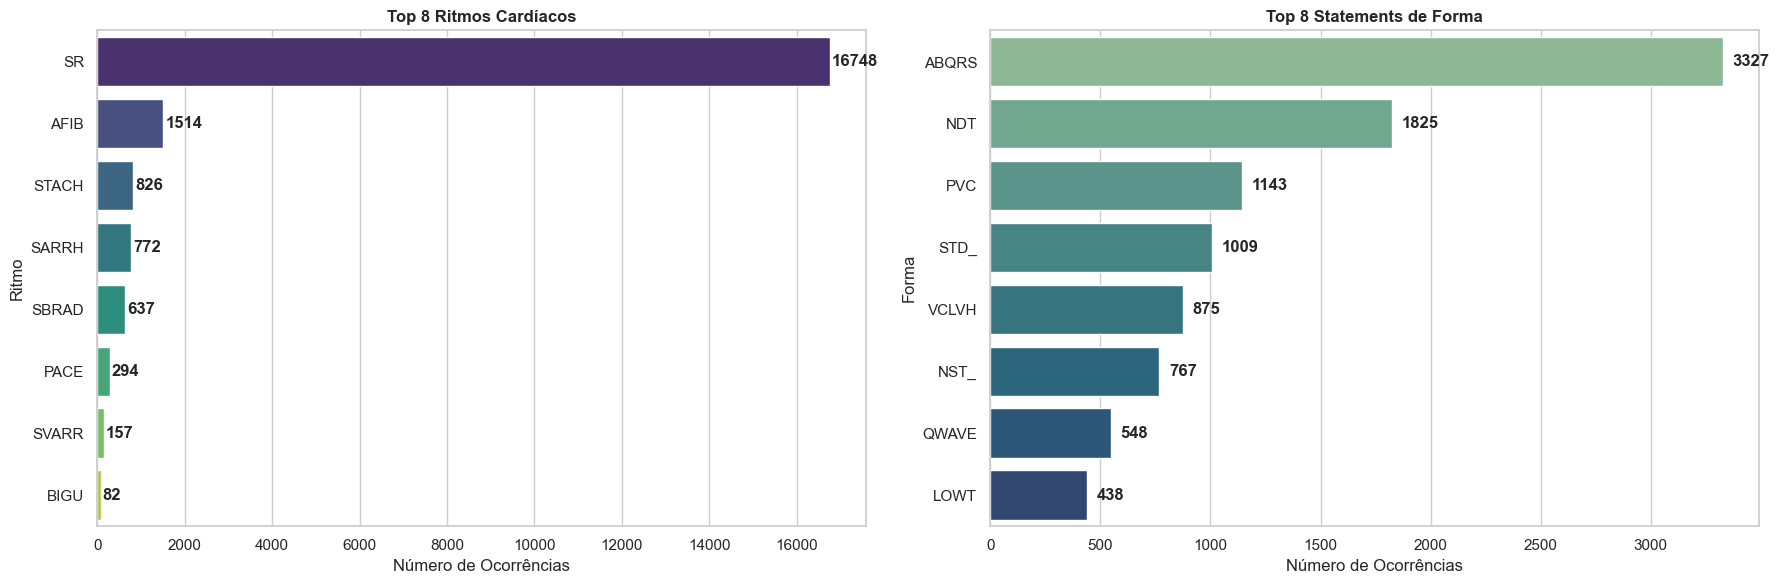

In [15]:
# ------------------------------
# FIGURA
# ------------------------------
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# --- Gráfico 1: Ritmos ---
sns.barplot(
    x=all_rhythms.head(8).values,
    y=all_rhythms.head(8).index,
    hue=all_rhythms.head(8).index,
    palette='viridis',
    dodge=False,
    ax=axes[0],
    legend=False
)

for i, v in enumerate(all_rhythms.head(8).values):
    axes[0].text(
        v + len(df)*0.002,
        i,
        f"{v}",
        va='center',
        fontweight='bold'
    )

axes[0].set_title('Top 8 Ritmos Cardíacos', fontweight='bold')
axes[0].set_xlabel('Número de Ocorrências')
axes[0].set_ylabel('Ritmo')

# --- Gráfico 2: Formas ---
sns.barplot(
    x=all_forms.head(8).values,
    y=all_forms.head(8).index,
    hue=all_forms.head(8).index,
    palette='crest',
    dodge=False,
    ax=axes[1],
    legend=False
)

for i, v in enumerate(all_forms.head(8).values):
    axes[1].text(
        v + len(df)*0.002,
        i,
        f"{v}",
        va='center',
        fontweight='bold'
    )

axes[1].set_title('Top 8 Statements de Forma', fontweight='bold')
axes[1].set_xlabel('Número de Ocorrências')
axes[1].set_ylabel('Forma')

# ------------------------------
# RESUMO TEXTUAL
# ------------------------------
print(f"=== Ritmos Cardíacos ( {len(all_rhythms)} ritmos distintos ) ===")
for idx, val in all_rhythms.items():
    print(f"{idx}: {val} ocorrências")

print(f"\n=== Top Statements de Forma ( {len(all_forms)} formas distintas ) ===")
for idx, val in all_forms.items():
    print(f"{idx}: {val} ocorrências")

# ------------------------------
# FINALIZAÇÃO
# ------------------------------
plt.tight_layout()
fig.savefig(os.path.join(FIGS_DIR, 'ritmo_forma.png'), dpi=150, bbox_inches='tight')
plt.show()

**Comentários sobre a subseção 2.3:**

A distribuição dos **ritmos cardíacos** mostra forte predominância de `SR` (ritmo sinusal), com 16.748 ocorrências, indicando que a maior parte dos registros apresenta atividade elétrica considerada fisiológica. Em contraste, ritmos anormais como `AFIB` (fibrilação atrial) aparecem com frequência bem menor (1.514 ocorrências), seguidos por `STACH` (taquicardia sinusal) e `SBRAD` (bradicardia sinusal). Ritmos mais específicos ou raros, como `PSVT`, `SVTAC` e `TRIGU`, possuem baixíssima ocorrência, evidenciando uma distribuição bastante desbalanceada entre classes.

Já os **statements de forma** apresentam maior diversidade (19 tipos distintos) e uma distribuição menos concentrada. Alterações como `ABQRS` (QRS anormal), `NDT` (alterações inespecíficas da onda T) e `PVC` (contrações ventriculares prematuras) estão entre as mais frequentes, sugerindo que alterações morfológicas no traçado são comuns mesmo quando não configuram necessariamente um diagnóstico fechado. Outras alterações, como `STE_`, `TAB_` e `PRC(S)`, aparecem com baixa frequência, reforçando a presença de classes raras.

Em comparação com os ritmos, os dados de forma indicam uma maior **heterogeneidade de padrões morfológicos**, enquanto os ritmos são dominados por poucos tipos principais. Essa diferença é relevante para modelagem, pois sugere que:
- Ritmos tendem a gerar **problemas de desbalanceamento mais severos**;
- Formas podem exigir maior capacidade do modelo para capturar **variações sutis no sinal**.

De forma geral, essa análise evidencia que o dataset combina uma base sólida de padrões normais com uma variedade significativa de alterações, tanto de ritmo quanto de forma, o que é importante para treinar modelos capazes de lidar com **variabilidade clínica real**, mas também impõe desafios relacionados ao **desbalanceamento de classes e representação de eventos raros**.

### 2.4 Multiplicidade de Registros por Paciente
Um paciente pode ter feito mais de um exame ao longo dos anos. É fundamental que todos os registros de um mesmo paciente estejam no mesmo fold do cross-validation para evitar data leakage.

In [16]:
# ------------------------------
# Registros por paciente + Verificação anti-leakage
# ------------------------------

# Contagem de registros por paciente
records_per_patient = df.groupby('patient_id').size().value_counts().sort_index()

df_records = pd.DataFrame({
    'Registros por paciente': records_per_patient.index,
    'Quantidade de pacientes': records_per_patient.values
})

# Percentual
df_records['Percentual (%)'] = (
    df_records['Quantidade de pacientes'] / df_records['Quantidade de pacientes'].sum() * 100
).round(4)

# Exibir tabela
display(df_records)

# ------------------------------
# Estatísticas descritivas
# ------------------------------
print("=== Estatísticas de registros por paciente ===")
display(df.groupby('patient_id').size().describe())

# ------------------------------
# Verificação de leakage
# ------------------------------
patients_in_multiple_folds = df.groupby('patient_id')['strat_fold'].nunique()
leakage_count = (patients_in_multiple_folds > 1).sum()

if leakage_count == 0:
    display(Markdown(
        "**Verificação anti-leakage aprovada:** todos os registros de um mesmo paciente estão contidos no mesmo fold. Sem risco de contaminação entre treino e teste."
    ))
else:
    display(Markdown(
        f"**Atenção:** {leakage_count} pacientes aparecem em mais de um fold. Investigar!"
    ))

,Registros por paciente,Quantidade de pacientes,Percentual (%)
0,1,16758,88.8123
1,2,1590,8.4265
2,3,350,1.8549
3,4,99,0.5247
4,5,43,0.2279
5,6,16,0.0848
6,7,5,0.0265
7,8,4,0.0212
8,9,3,0.0159
9,10,1,0.0053


=== Estatísticas de registros por paciente ===


count    18869.000000
mean         1.155281
std          0.523105
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         10.000000
dtype: float64

**Verificação anti-leakage aprovada:** todos os registros de um mesmo paciente estão contidos no mesmo fold. Sem risco de contaminação entre treino e teste.

---
## Seção 3 — Carregamento e Visualização do Sinal Bruto

### 3.1 Função de Carregamento com WFDB

Esta função tem como objetivo carregar o sinal bruto de ECG a partir do dataset PTB-XL utilizando a biblioteca `wfdb`. Dado um identificador de exame (`ecg_id`), ela localiza o arquivo correspondente no dataframe e retorna tanto o sinal (como array NumPy) quanto seus metadados. A função também permite escolher entre sinais com diferentes frequências de amostragem (100 Hz ou 500 Hz).

In [17]:
def load_ecg(ecg_id, dataframe, path_base, fs):
    """Carrega o sinal de ECG usando a biblioteca wfdb."""
    linha = dataframe.loc[ecg_id]
    file_target = linha['filename_lr'] if fs == 100 else linha['filename_hr']
    signal_arr, fields = wfdb.rdsamp(os.path.join(path_base, file_target))
    return signal_arr, fields

### 3.2 Seleção de Registros Representativos

Nesta etapa, são selecionados automaticamente alguns exames de ECG representativos para visualização dos sinais brutos. A escolha busca contemplar diferentes cenários clínicos e condições do sinal.

Para isso, são aplicados os seguintes critérios:

- **NORM (sinal limpo):** registro cuja única superclasse é `NORM`, validado por especialista (`validated_by_human == True`) e sem problemas de qualidade (ausência de baseline drift, ruído estático, ruído em rajada ou problemas de eletrodo declarada no `ptbxl_database.csv`).
- **MI (infarto):** registro que contém a superclasse `MI` em `diagnostic_superclass`.
- **AFIB (fibrilação atrial):** registro que possui o código `AFIB` presente em `scp_codes`.
- **Baseline drift:** registro que apresenta indicação de desvio de linha de base (`baseline_drift` não nulo).

O código prioriza registros validados por especialistas e sem interferências quando possível, garantindo exemplos variados e relevantes para análise visual. Caso não existam registros que satisfaçam completamente os critérios mais de qualidade, o código seleciona automaticamente alternativas disponíveis, garantindo que exemplos sejam sempre obtidos para visualização.

In [18]:
df['is_pure_norm'] = df['superclasses_clean'].apply(lambda x: x == ['NORM'])
df['has_quality_issues'] = df[['baseline_drift', 'static_noise', 'burst_noise', 'electrodes_problems']].notna().any(axis=1)

# Buscando exemplares variados por filtros programáticos
try:
    id_norm = df[(df['is_pure_norm']) & (df['validated_by_human'] == True) & (~df['has_quality_issues'])].index[0]
except IndexError:
    id_norm = df[df['is_pure_norm']].index[0]

try:
    id_mi = df[df['superclasses_clean'].apply(lambda x: 'MI' in x)].index[0]
except IndexError:
    id_mi = df.index[1]

try:
    id_afib = df[df['scp_codes'].apply(lambda d: 'AFIB' in d)].index[0]
except IndexError:
    id_afib = df.index[2]

try:
    id_baseline = df[df['baseline_drift'].notna()].index[0]
except IndexError:
    id_baseline = df.index[3]

registros_selecionados = {
    'NORM (sinal limpo)': id_norm,
    'MI (infarto)': id_mi,
    'AFIB (fibrilação atrial)': id_afib,
    'Baseline drift': id_baseline
}

display(Markdown("**Registros selecionados para visualização:**"))
for desc, eid in registros_selecionados.items():
    display(Markdown(f"- **{desc}**: ECG ID {eid} | Superclasse: {df.loc[eid, 'superclasses_clean']}"))

**Registros selecionados para visualização:**

- **NORM (sinal limpo)**: ECG ID 2 | Superclasse: ['NORM']

- **MI (infarto)**: ECG ID 8 | Superclasse: ['MI']

- **AFIB (fibrilação atrial)**: ECG ID 17 | Superclasse: []

- **Baseline drift**: ECG ID 4 | Superclasse: ['NORM']

### 3.3 Visualização das 12 Derivações

Nesta etapa, é implementada uma função para visualização dos sinais de ECG nas 12 derivações padrão clínicas. A função utiliza os sinais carregados previamente e organiza os traçados em uma grade 2×6, permitindo a inspeção simultânea de todas as derivações.

Cada subplot representa uma derivação específica, com o tempo no eixo horizontal e a amplitude do sinal em milivolts no eixo vertical. A padronização dos eixos e a inclusão de grade facilitam a comparação visual entre diferentes canais e registros.

Essa visualização é fundamental para análise qualitativa dos sinais, permitindo identificar padrões característicos de diferentes condições cardíacas, bem como possíveis artefatos ou problemas de qualidade nos dados.

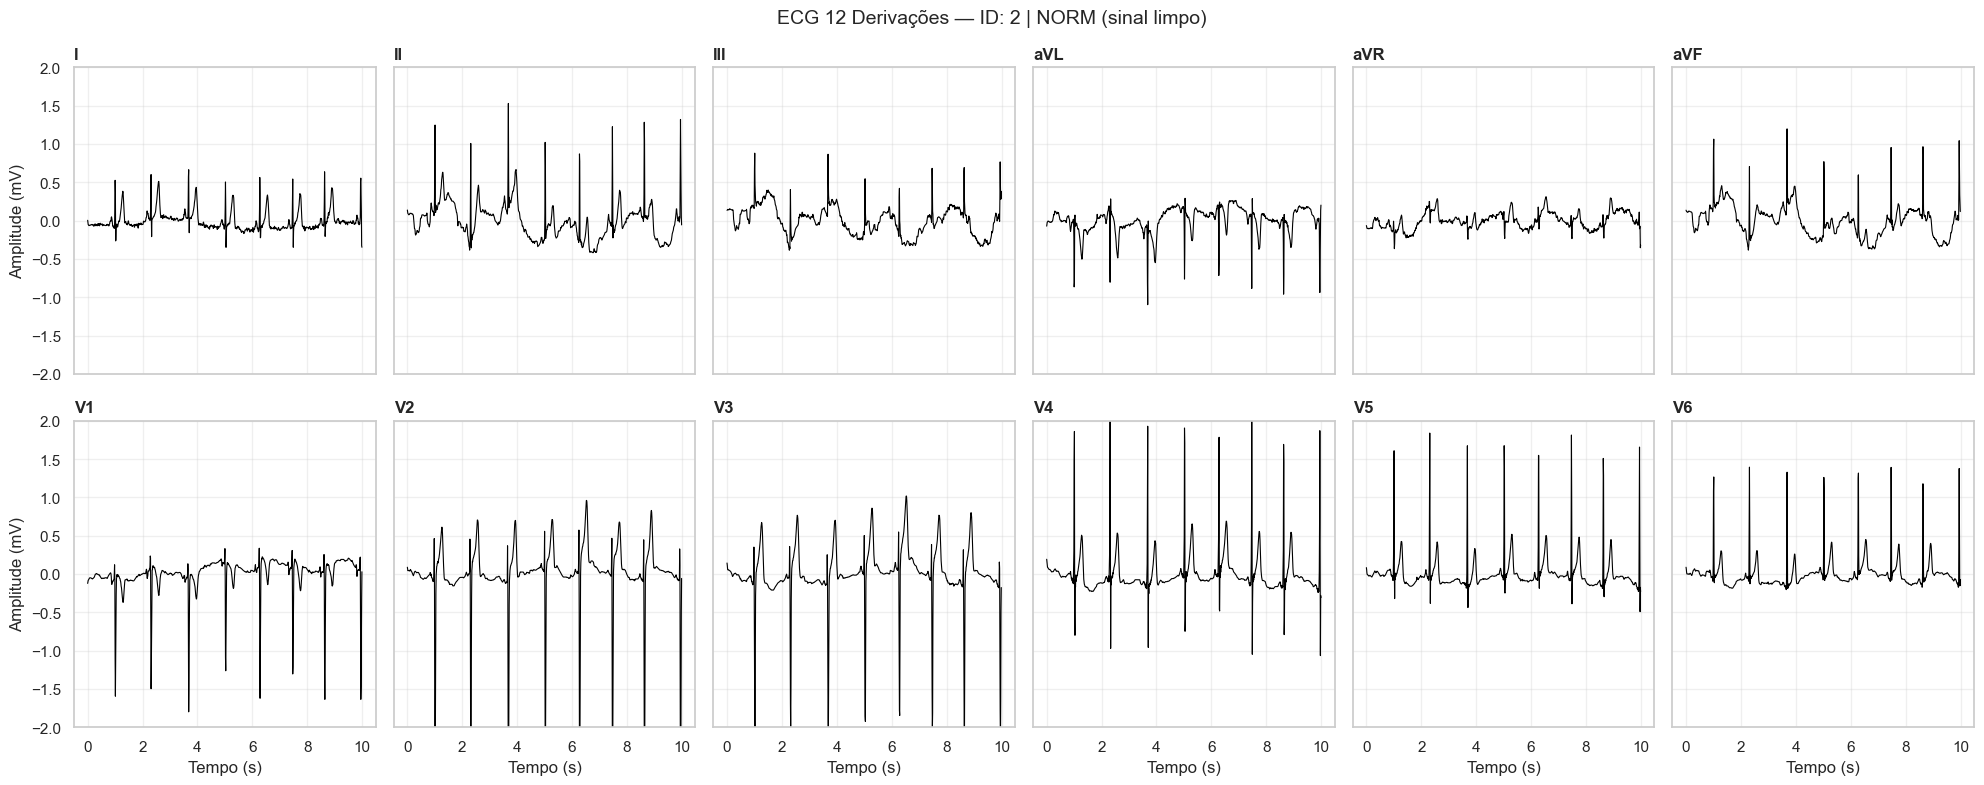

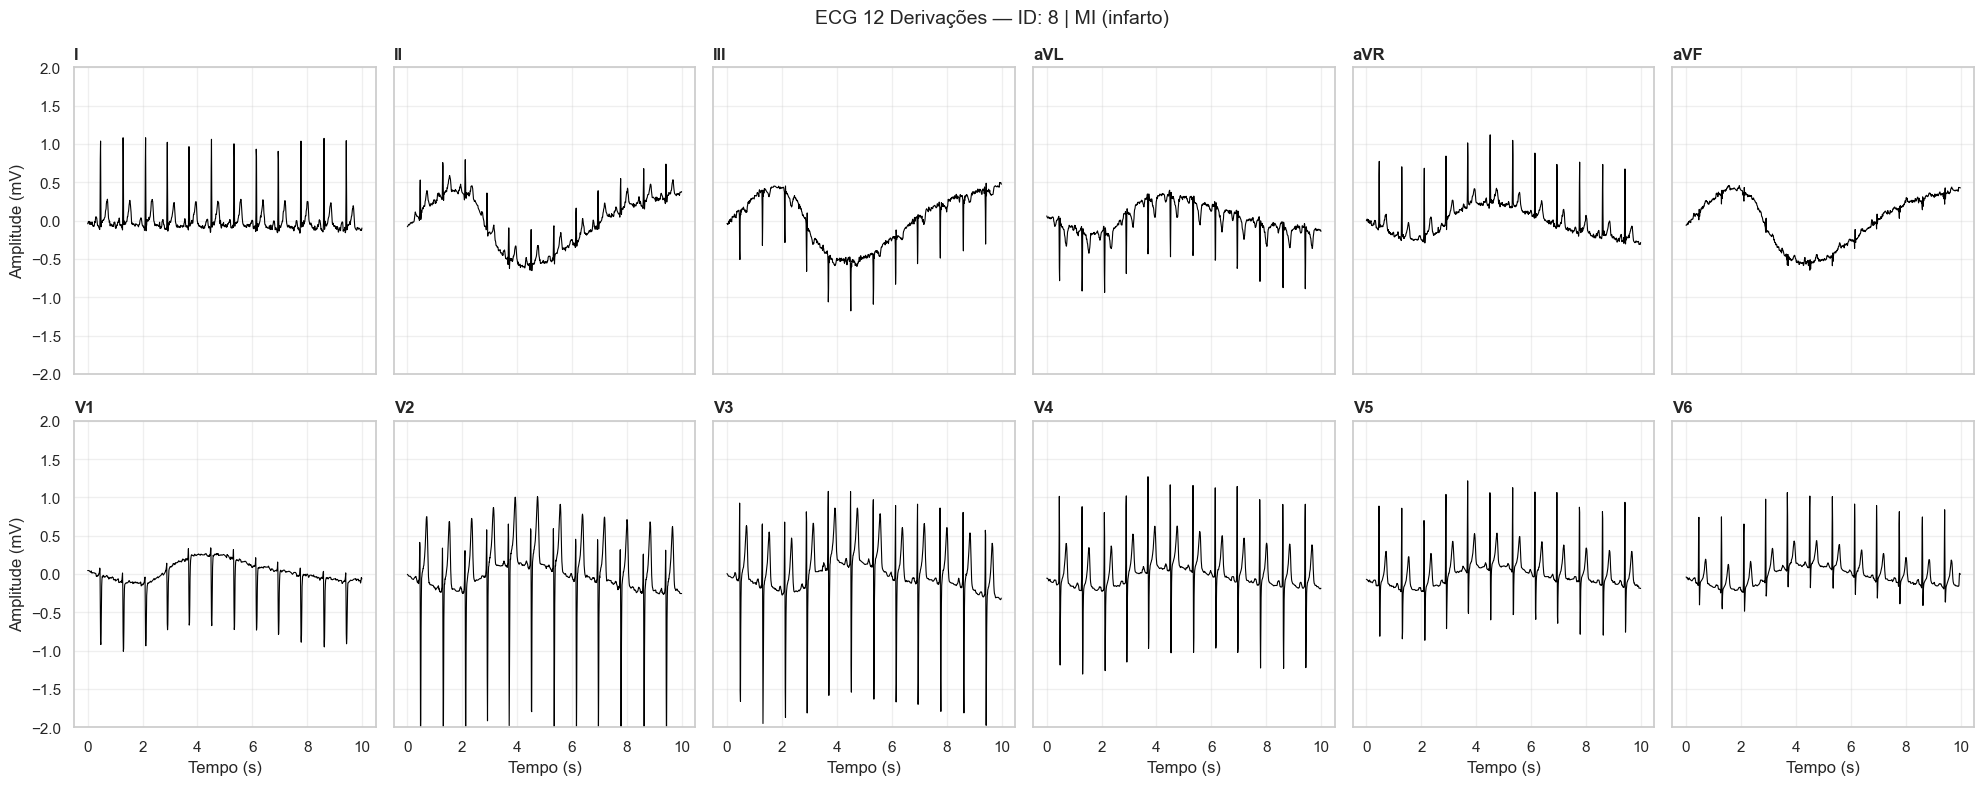

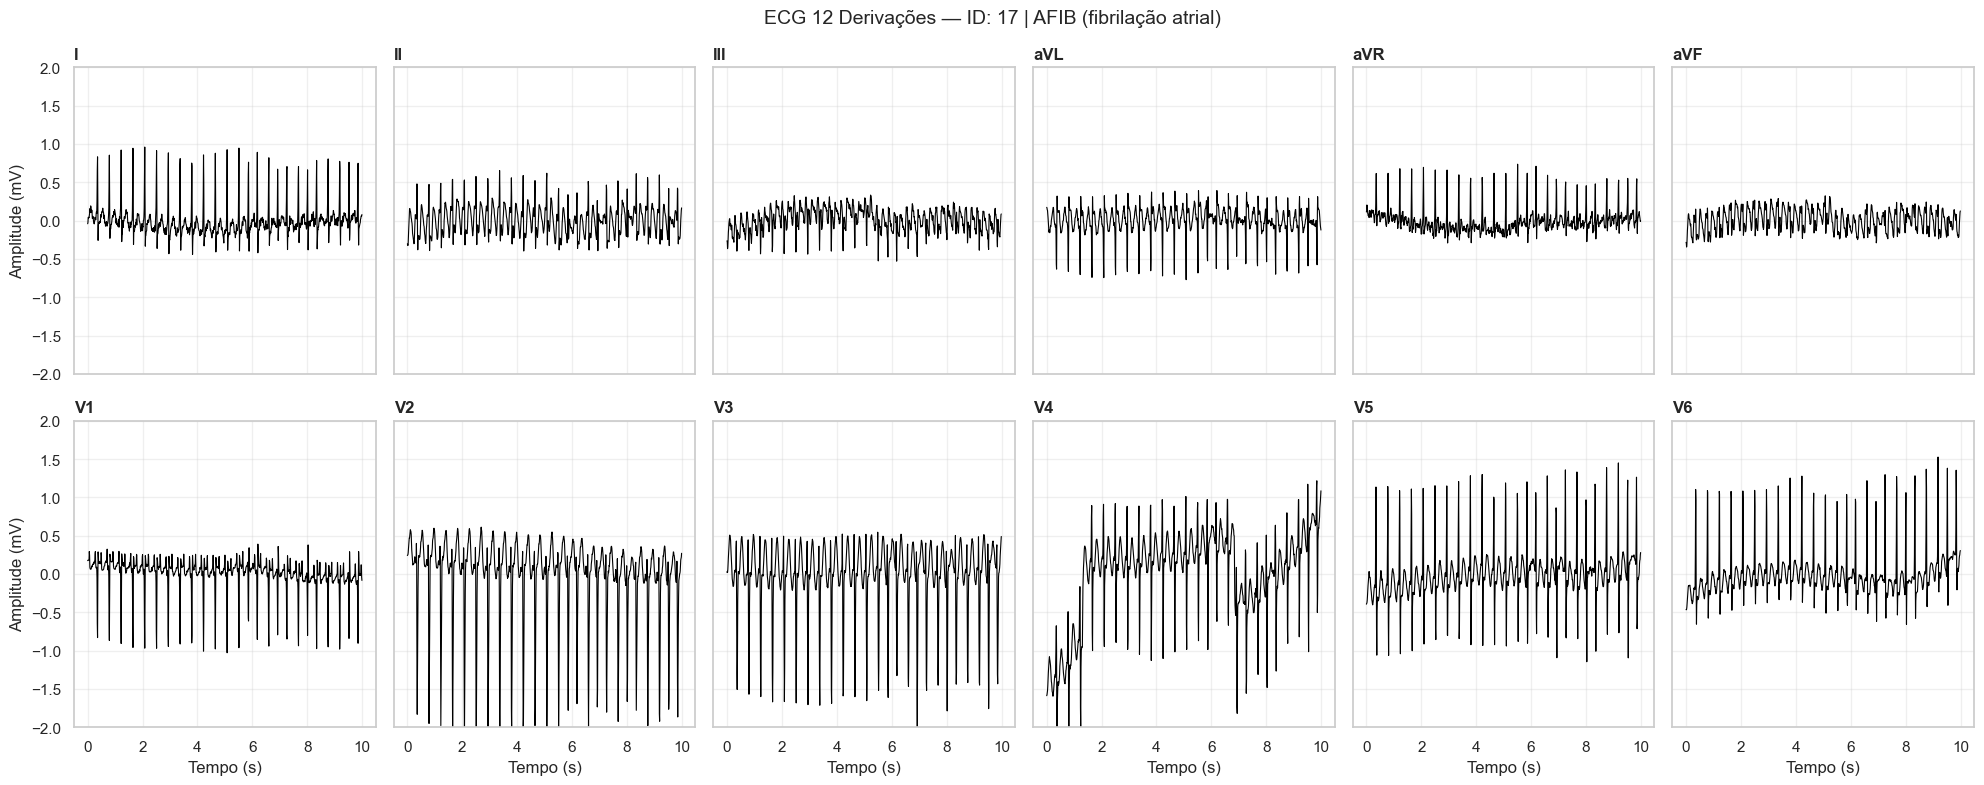

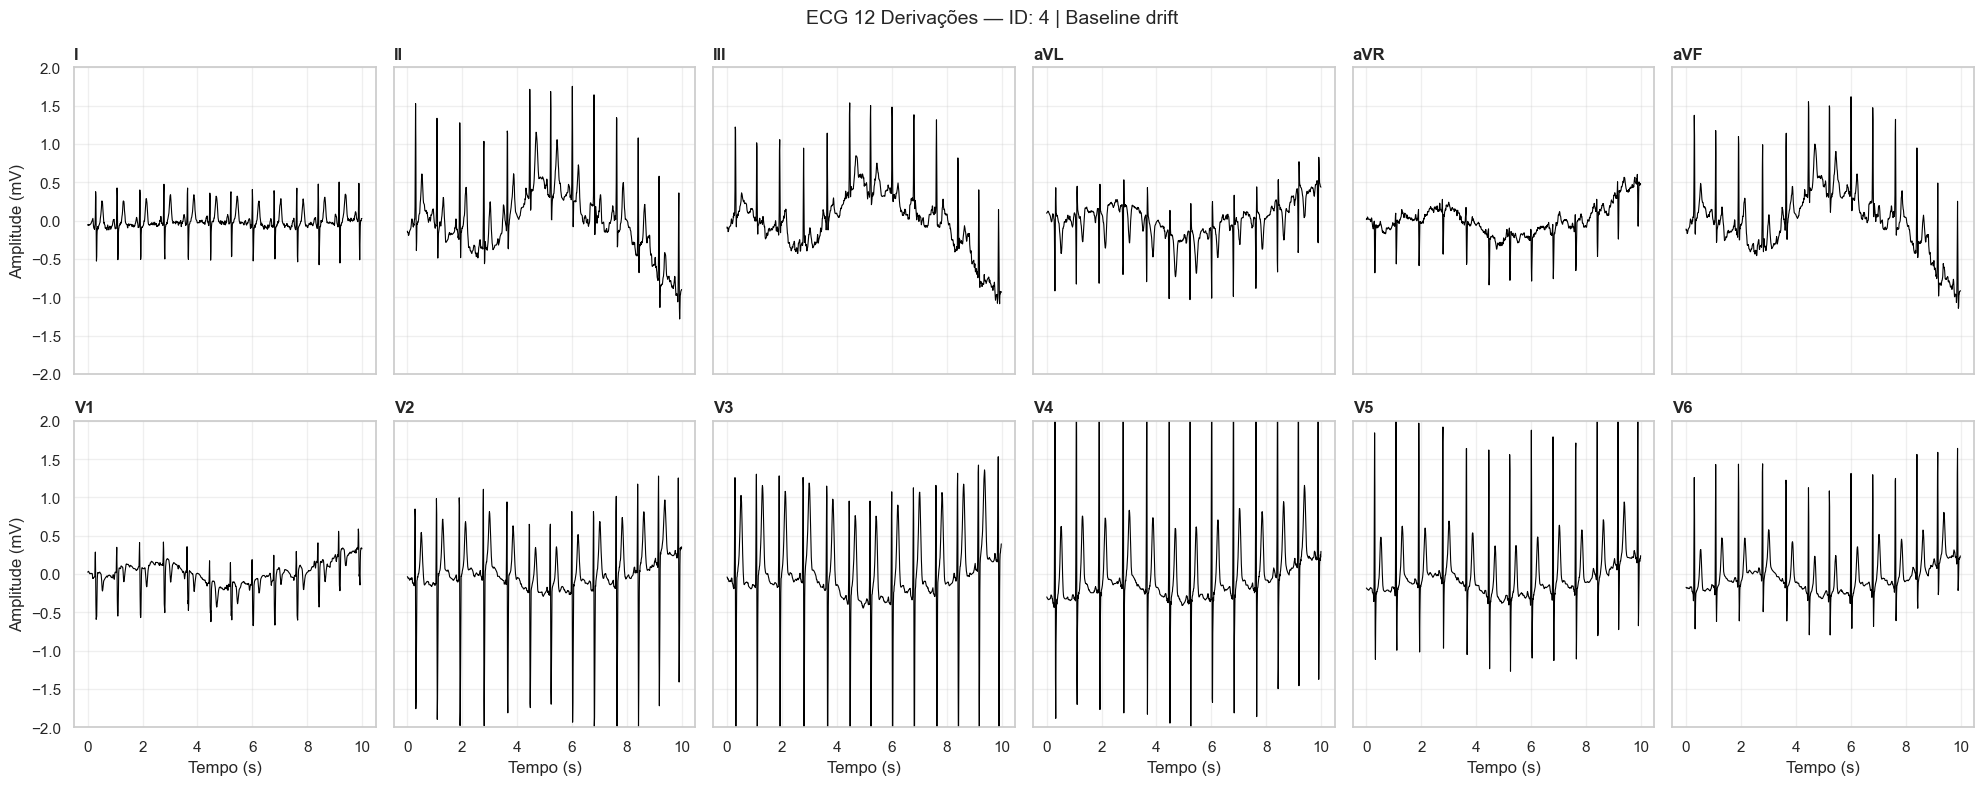

**(Espaço para comentário do aluno — dica: compare visualmente as morfologias. No registro NORM, espere ondas P, QRS e T bem definidas. No MI, procure por alterações de ST. No AFIB, note a ausência de onda P. No baseline drift, observe a oscilação lenta do eixo.)**

In [19]:
def plot_clinical_ecg(ecg_id, titulo_extra=""):
    sig, header = load_ecg(ecg_id, df, DATA_DIR, FS)
    t = np.arange(sig.shape[0]) / FS

    fig, axes = plt.subplots(2, 6, figsize=(20, 8), sharex=True, sharey=True)
    fig.suptitle(f'ECG 12 Derivações — ID: {ecg_id} | {titulo_extra}', fontsize=14)

    for i in range(12):
        row, col = i // 6, i % 6
        ax = axes[row, col]
        ax.plot(t, sig[:, i], color='black', linewidth=0.8)
        ax.set_title(LEAD_NAMES[i], loc='left', fontweight='bold')
        ax.set_ylim(-2, 2)
        ax.grid(alpha=0.3)
        if row == 1:
            ax.set_xlabel('Tempo (s)')
        if col == 0:
            ax.set_ylabel('Amplitude (mV)')

    plt.tight_layout()
    fig.savefig(os.path.join(FIGS_DIR, f'ecg_12leads_{ecg_id}.png'), dpi=150, bbox_inches='tight')
    plt.show()

for desc, eid in registros_selecionados.items():
    plot_clinical_ecg(eid, titulo_extra=desc)

display(Markdown("**(Espaço para comentário do aluno — dica: compare visualmente as morfologias. No registro NORM, espere ondas P, QRS e T bem definidas. No MI, procure por alterações de ST. No AFIB, note a ausência de onda P. No baseline drift, observe a oscilação lenta do eixo.)**"))

### Diretrizes para Interpretação Clínica de ECG

Fonte: [the_ecg_made_easy_8th_edition_medibos-blogspot-com_959](../../../docs/research/the_ecg_made_easy_8th_edition_medibos-blogspot-com_959.pdf)

A análise de eletrocardiogramas (ECG) de 12 derivações deve seguir uma abordagem sistemática e rigorosa. Embora sistemas automatizados forneçam interpretações, é fundamental realizar uma avaliação própria baseada em critérios clínicos bem estabelecidos.

A interpretação deve seguir a seguinte **sequência obrigatória**:

1. **Ritmo**
2. **Intervalos de condução** (PR, QRS, QT)
3. **Eixo cardíaco**
4. **Descrição dos complexos QRS**
5. **Descrição dos segmentos ST e ondas T**

---

#### 1. Ritmo Sinusal Normal (Indivíduo Saudável)

- **Ritmo:** Presença de ritmo sinusal, com cada onda P seguida por um complexo QRS e frequência entre 60–100 bpm.  
- **Intervalos:**  
  - PR entre 120–220 ms  
  - QRS ≤ 120 ms  
- **Eixo cardíaco:** Normal, entre -30° e +90°, com QRS positivo em I, II e III  
- **Segmento ST:** Isoelétrico (alinhado à linha de base)  
- **Onda T:** Geralmente positiva (exceto em aVR e V1)  

---

#### 2. Infarto do Miocárdio (IAM)

A análise deve focar na identificação e localização do dano miocárdico:

- **Segmento ST:** Elevação (supra de ST) é um dos primeiros sinais em casos agudos (STEMI)  
- **Ondas Q:** Presença de ondas Q patológicas (profundas ou largas), indicando necrose  
- **Localização do infarto:**  
  - **Anterior:** V2–V4  
  - **Inferior:** II, III e aVF  
  - **Lateral:** I, aVL, V5 e V6  
- **Onda T:** Pode tornar-se invertida após a fase aguda  

---

#### 3. Fibrilação Atrial (FA)

- **Ritmo:** Irregularmente irregular (sem padrão fixo)  
- **Ondas P:** Ausentes  
- **Linha de base:** Presença de ondas de fibrilação  
- **Complexos QRS:** Normalmente estreitos, porém distribuídos de forma irregular  

---

Essas diretrizes fornecem uma base para análise qualitativa dos sinais de ECG, permitindo relacionar padrões visuais observados nas derivações com condições clínicas específicas e reforçando a interpretação dos dados além da análise quantitativa.

**Comentários sobre a subseção 3.3:**

Fazendo uma análise bruta de cada sinal plotado acima, podemos dizer que a qualidade dos gráficos não ajudou muito em termos de estimativas de duração do intervalo PR e do complexo de QRS, mas permitiu uma visualizaçaão quase nítida das demais análises aconselhadas acima.

---

Para o sinal **NORM**, teoricamente em Ritmo Sinusal Normal, o ritmo parece levemente abaixo do esperado ( uma vez que só são possíveis contabilizar 8 Complexos QRS em 10 segundos, podemos afirmar que o ritmo está por volta de 48 bpm, o que é < 60 bpm ).

Já os intervalos de QRS e PR parecem extremamente maiores do que o esperados, uma vez que chegam a ocupar uma área significativa de cada quadradinho temporal ( equivalente a 2 segundos ).

Contudo, para a análise de Eixo Cardíaco, Segmento ST e Onda T, podemos dizer que apresenta o esperado, uma vez que corresponde ao que foi aconselhado anteriormente ( apesar de que, em muitos casos, ser complicado enxergar a onda S, mas podemos atribuir disso parte da culpa de nossa inexperiência analisando ECG's e o comprimento de cada parte do sinal ).

Um drift de baseline também pode ser facilmente perceptível em algumas das derivações plotadas, dentre elas a II, III, aVL, aVR, v1, etc.

---

Para o sinal **MI**, teoricamente em Infarto do Miocárdio, podemos perceber que o ritmo está dentro do esperado: 12 Complexos QRS em 10 segundos, equivalente a 72 bpm.

Contudo, para intervalos de condução, podemos ver uma maior tendência ao esperado em relação ao sinal NORM anterior: mesmo assim, é difícil dizer com precisão a duração desses intervalos justamente por conta deles serem muito pequenos em relação ao sinal plotado ( 120-220ms em um plot de 10s ); isso já nos levanta atenção à importância da criação de janelamentos de sinal, no futuro!

Agora, para provar o diagnóstico como MI e ainda indicar o tipo de infarto detectado, podemos prestar atenção nas derivações V2, V3 e V4: não é difícil perceber que nelas o segmento ST está MUITO elevado em relação ao esperado ( em especial, a onda T está elevada, superando a R durante todo a derivação V2 ). Adicionalmente, também nessas derivações, é possível notar as ondas Q patológicas ( todos têm ondas Q MUITO profundas ).

Já os infartos Inferior e Lateral não estão presentes, haja vista que as derivações II, III, aVF, I, aVL, V5 e V6 estão relativamente normais e dentro dos padrões esperados ( apesar de ser possível ver drifts absurdos em algumas como II, III e aVF, e um estranho apagamento da aVF, provavelmente por mal contato do eletrodo relacionado ).

---

Para o sinal **AFIB**, teoricamente em Fibrilação Atrial, o sinal aparenta estar completamente caótico e conflitante, com uma kurtose absurda e ritmo extremamente acelerado ( apesar de pouco perceptível que é variável, com maior evidência de amplitudes irregulares ).

As ondas P parecem visíveis em especial nas derivações I, V5 e V6, estando ausentes ou simplesmente impossíveis de visualizar nas demais ( destaque especial à III e aVF, que basicamente são apenas alguns ruídos aleatórios em um papel ).

As ondas de fibrilação são bem perceptíveis, tornando toda a base do sinal um aglomerado de pequenas e densas fibrações, vez ou outra interrompidas por uma onda R extremamente acentuada ( com exceção da derivação aVF, que sequer é possível distinguir ondas ).

Em termos do quão estreitos os Complexos QRS estão, de fato estão como o esperado: estreitos e rápidos, demonstrando claramente que, pelo menos de acordo com o que vimos na referência para análise de Fibrilação Atrial, esse sinal de fato parece merecer esse diagnóstico.

Drift de baseline é perceptível, sendo claramente forte na derivação V4.

---

Já para o sinal plotado apenas para evidenciar **Baseline Drift**, podemos notar a evidência desse fenômeno bem acentuada nas derivações II, III, aVL, aVR, aVF, V1 e V6 ( nas demais também é notável, mas essas merecem destaque ). Infelizmente os sinais anteriormente plotados também demonstrava, por vezes, drifts da baseline ainda mais expressivos do que os deste, então não há muito a complementar com esse sinal: ele apenas nos mostra como a variação da linha de base pode se parecer!

### 3.4 Análise Espectral do Sinal Bruto (Derivação DII - II)

A análise espectral do sinal de ECG permite observar como a energia do sinal está distribuída ao longo das frequências, complementando a visualização no domínio do tempo. Esse tipo de abordagem é especialmente útil em sinais biomédicos, como o ECG, que apresentam componentes periódicas bem definidas e são suscetíveis a diferentes tipos de ruído.

Para estimar o espectro de potência, utiliza-se o método de Welch, que consiste na divisão do sinal em segmentos sobrepostos e no cálculo da média dos periodogramas, resultando em uma estimativa mais estável e com menor variância.

Essa análise é particularmente relevante para:
- Identificar a faixa de frequência onde se concentra a maior parte da energia do ECG (tipicamente abaixo de 30–40 Hz);
- Detectar ruídos e artefatos, como baseline drift (baixas frequências), ruído muscular (altas frequências) e interferência da rede elétrica (~50 Hz);
- Fundamentar a escolha de filtros passa-alta e passa-baixa, que serão aplicados posteriormente no pré-processamento.

Dessa forma, esta etapa estabelece uma referência do sinal bruto (o "antes"), permitindo comparação com versões filtradas (o "depois") e avaliação da eficácia das técnicas de limpeza do sinal que serão aplicadas no Entregável 4.

---

**Referências:**
- Subseção 17.2.3.1 do: [Leveraging_Data_Scicence_for_Global_Health](../../../docs/research/Leveraging_Data_Science_for_Global_Health.pdf)  
- Sobre o Método Welch: [An_Ensemble_Learning_Approach_for_Electrocardiogram_Sensor_Based_Human_Emotion_Recognition](../../../docs/research/An_Ensemble_Learning_Approach_for_Electrocardiogram_Sensor_Based_Human_Emotion_Recognition.pdf)


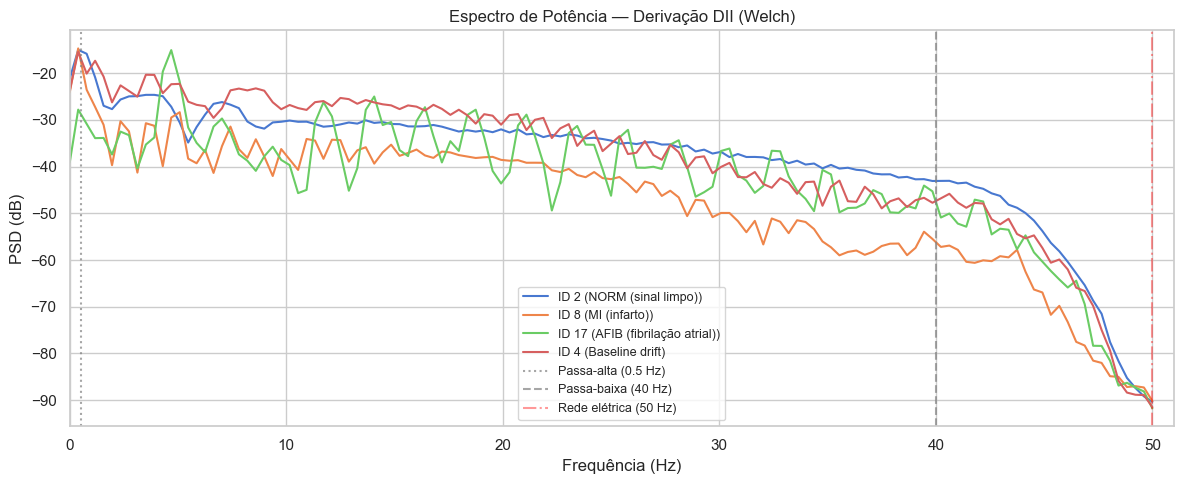

In [20]:
fig = plt.figure(figsize=(12, 5))

for desc, eid in registros_selecionados.items():
    sig, _ = load_ecg(eid, df, DATA_DIR, FS)
    dii = sig[:, 1]
    freqs, psd = signal.welch(dii, fs=FS, nperseg=256)
    psd_db = 10 * np.log10(psd + 1e-10)
    plt.plot(freqs, psd_db, label=f'ID {eid} ({desc})')

plt.axvline(0.5, color='gray', linestyle=':', alpha=0.7, label='Passa-alta (0.5 Hz)')
plt.axvline(40, color='gray', linestyle='--', alpha=0.7, label='Passa-baixa (40 Hz)')
plt.axvline(50, color='red', linestyle='-.', alpha=0.4, label='Rede elétrica (50 Hz)')

plt.xlim(0, FS/2 + 1)
plt.xlabel('Frequência (Hz)')
plt.ylabel('PSD (dB)')
plt.title('Espectro de Potência — Derivação DII (Welch)')
plt.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, 'espectro_welch_bruto.png'), dpi=150, bbox_inches='tight')
plt.show()

### Comentário sobre a subseção 3.4:

A análise espectral das derivações DII revela que a maior parte da energia dos sinais de ECG está concentrada nas baixas frequências, principalmente entre aproximadamente 0.5 e 10 Hz. A partir dessa faixa, observa-se um decaimento progressivo e lentoda densidade espectral de potência, que se torna mais regular entre 10 Hz e 40 Hz, especialmente no sinal normal, o que não é consistente com a natureza fisiológica do ECG, que tem suas componentes principais (ondas P, QRS e T) distribuídas principalmente na faixa de 30-40Hz; contudo, isso já havia sido notado na seção 3.3; provavelmente é um efeito apenas notado no conjunto escolhido para ser analisado nesta parte, não devendo ser algo geral dos demais registros.

Observa-se também que todos os registros apresentam uma queda acentuada da densidade espectral de potência (PSD) à medida que a frequência se aproxima de 50 Hz, indicando baixa contribuição de componentes de alta frequência no sinal bruto. A ausência de picos expressivos exatamente em 50 Hz sugere que a interferência da rede elétrica não é dominante nesses exemplos, embora pequenas contribuições possam estar presentes.

O registro com *baseline drift* apresenta maior energia nas baixas frequências (próximo de 0 Hz), o que é esperado, já que esse tipo de ruído se manifesta como variações lentas na linha de base. Já o sinal de *fibrilação atrial (AFIB)* apresenta uma distribuição espectral bastante irregular, com sucessivos picos e vales ao longo da faixa de 0 a 40 Hz, formando um padrão quase oscilatório que reflete a natureza caótica e desorganizada da atividade elétrica atrial. Por outro lado, o registro de *infarto do miocárdio (MI)* apresenta níveis de potência globalmente inferiores em praticamente todo o espectro, o que pode estar associado a alterações na propagação do impulso elétrico e à redução da atividade elétrica efetiva em regiões do miocárdio comprometidas.

Além disso, ao estender o limite do gráfico até aproximadamente FS/2, observa-se que o espectro naturalmente se extingue próximo da frequência de Nyquist, evidenciando que não há conteúdo informativo relevante além desse limite. Isso reforça o entendimento teórico de que, para um sinal amostrado, toda a informação espectral está contida no intervalo de 0 até FS/2.

De forma geral, essa análise fornece uma visão clara do comportamento espectral do sinal bruto e estabelece uma referência importante para avaliar, posteriormente, o impacto das etapas de filtragem.

---
## Seção 4 — Enriquecimento do Metadado e Salvamento

### 4.1 Adição de Colunas Calculadas

Nesta etapa, o conjunto de metadados é enriquecido com informações derivadas que facilitam sua utilização nas etapas posteriores do pipeline. Em particular, é criada a coluna `split`, que define a divisão dos dados em conjuntos de treino, validação e teste com base na estratégia de *cross-validation* estratificada previamente estabelecida.

Essa separação é essencial para garantir uma avaliação adequada de modelos, evitando vazamento de dados (*data leakage*) e assegurando que os resultados obtidos reflitam a capacidade de generalização do modelo.

Além disso, opta-se por manter tanto os dados processados (como `superclasses_clean` e `rhythm_clean`) quanto a coluna original `scp_codes`. Embora esta última seja mais complexa, ela representa a fonte bruta das anotações clínicas e preserva flexibilidade para análises futuras ou redefinição de rótulos. Por outro lado, colunas auxiliares intermediárias, como `age_clean`, são removidas por não agregarem valor adicional nesta etapa.

In [21]:
def get_split(fold):
    if fold in FOLDS_TREINO:
        return 'train'
    elif fold == FOLD_VAL:
        return 'val'
    elif fold == FOLD_TEST:
        return 'test'
    return 'unknown'

df['split'] = df['strat_fold'].apply(get_split)

# Limpando colunas auxiliares
colunas_para_remover = ['age_clean']  # adicionar outras se necessário
df.drop(columns=colunas_para_remover, inplace=True, errors='ignore')

### 4.2 Salvamento do Dataset Enriquecido

Após o enriquecimento, o DataFrame é salvo em formato `.csv`, permitindo seu reaproveitamento nas próximas etapas do projeto sem a necessidade de repetir o pré-processamento.

Também são calculadas estatísticas descritivas simples, como o número de registros em cada *split* (treino, validação e teste) e a quantidade de sinais com problemas de qualidade anotados. Essas informações fornecem uma visão geral da composição do dataset e permitem verificar aspectos importantes, como o balanceamento entre conjuntos e a presença de possíveis limitações nos dados.

A manutenção simultânea de colunas processadas e da fonte original de anotações garante que o dataset final seja ao mesmo tempo prático para uso imediato e suficientemente rico para investigações futuras.

Essa etapa finaliza a preparação do metadado, consolidando todas as transformações realizadas e estabelecendo uma base estruturada, consistente e pronta para as fases seguintes de análise e modelagem.

In [22]:
# 4.2 Salvamento
caminho_resultado = '../outputs/ptbxl_metadata_enriched.csv'
df.to_csv(caminho_resultado)

n_train = len(df[df.split == 'train'])
n_val = len(df[df.split == 'val'])
n_test = len(df[df.split == 'test'])
n_problemas = df['has_quality_issues'].sum() if 'has_quality_issues' in df.columns else 0

display(Markdown(f"""
**Arquivo salvo em:** `{caminho_resultado}`

| Split | Registros |
|---|---|
| Treino (folds 1–8) | {n_train} |
| Validação (fold 9) | {n_val} |
| Teste (fold 10) | {n_test} |

Registros com problemas de qualidade anotados: **{n_problemas}**
"""))


**Arquivo salvo em:** `../outputs/ptbxl_metadata_enriched.csv`

| Split | Registros |
|---|---|
| Treino (folds 1–8) | 17418 |
| Validação (fold 9) | 2183 |
| Teste (fold 10) | 2198 |

Registros com problemas de qualidade anotados: **5010**


---
## Seção 5 — Síntese e Conexão

Ao longo deste entregável, foi construída uma base sólida para análise de sinais de ECG a partir do dataset PTB-XL, integrando conceitos teóricos de processamento de sinais com práticas de manipulação e exploração de dados reais.

Inicialmente, estabeleceu-se o contexto clínico e técnico do problema, destacando a relevância do eletrocardiograma como ferramenta diagnóstica e a importância do critério de Nyquist para garantir a correta representação dos sinais no domínio digital. Essa fundamentação assegura que todas as análises subsequentes sejam interpretadas dentro de limites físicos e matemáticos bem definidos.

Em seguida, a análise estatística do dataset permitiu compreender sua estrutura e possíveis limitações, como distribuições desbalanceadas entre classes diagnósticas, diversidade de ritmos e presença de múltiplos registros por paciente. Essa etapa foi essencial para contextualizar os dados e orientar decisões posteriores, especialmente no que diz respeito à seleção de amostras e interpretação dos resultados.

A etapa de análise do sinal bruto consolidou a ponte entre teoria e prática. A visualização das 12 derivações evidenciou a complexidade e riqueza do ECG, enquanto a análise espectral revelou que a maior parte da energia dos sinais está concentrada em baixas frequências, com comportamentos distintos entre registros normais e patológicos. Essas observações não apenas validam o conhecimento fisiológico esperado, como também fornecem base técnica para o tratamento do sinal.

Por fim, o enriquecimento do metadado e sua organização em *splits* de treino, validação e teste estabelecem uma base estruturada e reutilizável para as próximas fases do projeto. A decisão de manter tanto as colunas processadas quanto as informações brutas (como `scp_codes`) garante um equilíbrio entre praticidade e flexibilidade analítica.

Como continuidade direta deste trabalho, o Entregável 2 terá foco na avaliação da qualidade dos sinais por meio de métricas de *Signal Quality Index* (SQI), permitindo quantificar e filtrar registros com base em critérios objetivos de qualidade. Já o Entregável 3 aprofundará as análises exploratórias e interpretativas, utilizando os sinais previamente organizados e avaliados para extrair informações mais refinadas e potencialmente relevantes do ponto de vista clínico e computacional.

De forma integrada, todas essas etapas constroem um pipeline coerente que vai desde a aquisição e compreensão dos dados até sua preparação para análises mais avançadas. Mais do que executar procedimentos isolados, o trabalho demonstra uma linha de raciocínio consistente, onde cada decisão é sustentada por fundamentos teóricos e observações empíricas, garantindo robustez às etapas subsequentes do projeto.